# Industrial Defect Intelligence
## Handcrafted gradients and learned representations for steel-surface defect classification

**Research question:** To what extent does end-to-end representation learning improve multiclass steel-surface defect classification over handcrafted HOG features, and are any performance gains maintained under validation, image-condition variation and practical deployment constraints?

This empirical study compares a bounded HOG-SVM search with one compact, CPU-trained CNN on the same locked development folds and test images. It addresses the Computer Vision assignment through data quality, controlled model development, required classification metrics, explainability, robustness, efficiency and responsible deployment. It classifies **six known defect categories**: crazing, inclusion, patches, pitted surface, rolled-in scale and scratches. There is no normal-steel class, localisation task or deployed application. Classification accuracy cannot establish defect-versus-normal detection, engineering acceptability or factory readiness.

**Principal finding.** The frozen CNN improves clean-test macro F1 from 0.9023 to 0.9555, but its advantage reverses under the declared blur and contrast stresses. The evidence supports further supervised assessment, with condition-specific and per-class scrutiny, rather than automatic material disposition.

**Reading order:** reproducibility and provenance; experimental design; model development and epoch sensitivity; locked-test findings; explanations and condition diagnostics; robustness, efficiency and deployment; references. Tables use scores on a 0 to 1 scale unless stated otherwise. Display rounding never changes the saved evidence.

## 1. Reproducibility and evidence boundary

This is an **artefact-based reproduction of the final study**. Run from the project root using Restart Kernel and Run All. It reads frozen results, checks their SHA-256 digests, recomputes metrics from saved predictions and displays the original figures. Default execution does not train models, perform new test inference, regenerate split assignments or overwrite experimental outputs. Saved outputs make the notebook readable without executing it; rerunning requires the accompanying project artefacts listed in its integrity cell. No development notebook is imported or executed.

Use Python 3.14.0, as recorded for the experiment. In a separate environment, the exact minimal commands for this notebook are:

```text
python -m venv .venv-submission
.venv-submission\Scripts\python.exe -m pip install numpy==2.5.3 pandas==3.0.6 pillow==12.3.0 scikit-learn==1.9.1 ipython==9.17.1 ipykernel==7.3.0 nbformat==5.11.1 nbclient==0.11.0 jupyterlab==4.6.4
.venv-submission\Scripts\python.exe -m ipykernel install --user --name industrial-defect-submission --display-name "Industrial Defect Submission"
.venv-submission\Scripts\python.exe -m jupyterlab
```

Select that kernel. These are recorded environment versions, not a claim that package availability has been independently tested on a clean machine. The full frozen environment is in `outputs/experiments/05_comparison_xai_robustness/reproducibility/pip_freeze.txt`. For a separate future modelling reproduction, the recorded additional dependencies are:

```text
python -m pip install matplotlib==3.11.2 scikit-image==0.26.0 joblib==1.6.0 torch==2.14.0 torchvision==0.29.0 captum==0.9.0
```

Section 14 contains the HOG-SVM and CNN implementation with `RUN_FULL_TRAINING = False` by default. Enabling it deliberately runs development-only training into new reproduction folders; it never runs locked-test inference or replaces frozen evidence. These optional implementation cells have not been executed in this consolidated notebook. Its default reproduction is the analysis of frozen evidence, not a claim of retraining from an empty folder. Original protocols, seeds, checkpoints, predictions and environment records accompany the project. Section 13 supplies a disabled, isolated input-restoration procedure. Cross-platform training equality and fresh package installation have not been established.

**Evidence precedence.** Run identities come from the final evaluation's saved source inventory, not a search for the best score. The current provenance record supersedes historical provenance warnings. Older CNN prose quoted timing from another run; the development and deployment timings below come from the exact run used in the frozen comparison.

In [1]:
from pathlib import Path
from importlib.metadata import version
import hashlib
import json
import platform
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

ROOT = Path.cwd().resolve()
if not (ROOT / 'outputs/metrics/split_lock.json').is_file():
    raise FileNotFoundError('Start the notebook in the project root containing outputs/metrics/split_lock.json.')
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
pd.set_option('display.precision', 6)

def sha(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def read_json(relative):
    return json.loads((ROOT / relative).read_text(encoding='utf-8'))

def read_table(relative, **kwargs):
    return pd.read_csv(ROOT / relative, **kwargs)

def show_table(relative, caption, columns=None, index=False):
    frame = read_table(relative, index_col=0 if index else None)
    if columns is not None:
        frame = frame[columns]
    display(Markdown('**' + caption + '**'))
    display(frame.style.format(precision=6, na_rep='').hide(axis='index') if not index else frame.style.format(precision=6, na_rep=''))

def show_figure(relative, caption, width=1050):
    display(Markdown('**' + caption + '**'))
    display(Image(filename=str(ROOT / relative), width=width))

In [2]:
# Frozen evidence inventory. Models are hashed as bytes, never deserialised.
# New generated artefacts belong in a separate directory, never in frozen run folders.
EVIDENCE_SHA256 = {
  "data/NEU-CLS/Dataset-Information.txt": "7316174917fd5d1ab542a52421a2b473e234d32f5bc1acbf1cc6b09b5db725d7",
  "outputs/experiments/03_hog_svm_20260923T232217_532748Z/cv_candidate_summary.csv": "0d973a01ac95e40ccf55f54c190cdd2a0fc2160f5c5d8b64722b7bb45f58ac14",
  "outputs/experiments/03_hog_svm_20260923T232217_532748Z/hog_svm_development.joblib": "515ab1afcde334f57828149c6c3c7d0a5f2a5e1fc0e371e81aa7c62f5b36443a",
  "outputs/experiments/03_hog_svm_20260923T232217_532748Z/protocol.json": "4bb986c9247b47039fca1d25c83db9c72be6afb6ff74d3158f023c72ad4c7f84",
  "outputs/experiments/03_hog_svm_20260923T232217_532748Z/result.json": "00f7eede883641950f6b3849ff5d7515d450e1292e2e84cebc7a2f3fdf813af0",
  "outputs/experiments/04_cnn_20260925T222923_890724Z/checkpoints/cnn_final_development.pt": "0cc0e297c5754c18727a697502e557a2dd8faa783d2c3d6b4e38881fc8e0007b",
  "outputs/experiments/04_cnn_20260925T222923_890724Z/fold_learning_curves.png": "5152d78114677b6d6658524cb2ff57b422d7825a31490977011d9410c281ee75",
  "outputs/experiments/04_cnn_20260925T222923_890724Z/fold_metrics.csv": "e034ddc9783adef8e670ef26b95178c36f75bc0b9abc8bfa432e649804610e7d",
  "outputs/experiments/04_cnn_20260925T222923_890724Z/protocol.json": "7dd460c0a2e4d3e7acad3f87a1cf3af2d3a57cb5e3da359e9edc90bce5a4b344",
  "outputs/experiments/04_cnn_20260925T222923_890724Z/result.json": "44d07bb83d965ebb61b033fd9f7c09bbc5e63d726d467cd76bc7bae61180a831",
  "outputs/experiments/04a_cnn_epoch_sensitivity_20260926T000504_973861Z/final_cnn_budget_specification.json": "55c204629b7acd5843a5d6a71b5015ea1ae464cc4038623a418d1ba1526fea52",
  "outputs/experiments/04a_cnn_epoch_sensitivity_20260926T000504_973861Z/paired_25_vs_40_fold_results.csv": "602a904de5e4d75081bb98ac3514de60604344e238af51d494c0906cbad454a2",
  "outputs/experiments/04a_cnn_epoch_sensitivity_20260926T000504_973861Z/protocol.json": "b8ba074e859d1e2c83b37a3de40b5fd67e003fe68273c302bb07142bf4f1eaa5",
  "outputs/experiments/04a_cnn_epoch_sensitivity_20260926T000504_973861Z/result.json": "6c75544aca3c3e801b81967ae2d2a1cdc15748b428dec529835ebda0406864a1",
  "outputs/experiments/04a_cnn_epoch_sensitivity_20260926T000504_973861Z/validation_loss_f1_25_vs_40.png": "26551973cc525ef3acef67715774a2224b9fb8580b65b81bf14dc1446d234b85",
  "outputs/experiments/05_comparison_xai_robustness/cache/clean_predictions.npz": "5c7b9c8b429a9ecfd52f562ad1fd3c3904f7dd7ced1512bb2963d979c881cd17",
  "outputs/experiments/05_comparison_xai_robustness/cache/clean_receipt.json": "e1eb2849ac6be9ade4b20043b911aeb067182cabe41fdf6a9e26d53bacb22a4c",
  "outputs/experiments/05_comparison_xai_robustness/figures/clean_confusion_matrices.png": "c4e01ca3b872e68d35b0918c291f8f67c3cd04e447ca8dd5ff56cb340930ee10",
  "outputs/experiments/05_comparison_xai_robustness/figures/gradcam_and_hog_cases.png": "8ce9629f6ed65e74fff769fe5b629422e47e019bc44697020cb9fca75b23d1c6",
  "outputs/experiments/05_comparison_xai_robustness/figures/robustness_deltas.png": "9528cf4461ee72f5f371c6cb4bc686ccdbd3638dd0fe71b610632c2cc18b78c5",
  "outputs/experiments/05_comparison_xai_robustness/reports/predeclared_protocol.json": "9d88de997d99097847962ebf404c75dc37260fe9800f029ee6b017ae02ed2bf9",
  "outputs/experiments/05_comparison_xai_robustness/reports/result.json": "70ca479e195a878d26645f58ce2fd69b37f3ae636711c85b515e177d34750cbf",
  "outputs/experiments/05_comparison_xai_robustness/reproducibility/environment.json": "965b5239619baa9df976bf9809bc0f167ea2a0d1cedccd8eacf1530a3afef517",
  "outputs/experiments/05_comparison_xai_robustness/reproducibility/pip_freeze.txt": "b694a1c9ffd7d10146ea66d04a00772f7a3f179fd68529ed174b837e1c2a9d88",
  "outputs/experiments/05_comparison_xai_robustness/reproducibility/source_inventory.json": "c360bfa32e6ae4c9f8d8765f169fd1e2fecea6b27d6045cab766937d7417d5c5",
  "outputs/experiments/05_comparison_xai_robustness/tables/clean_metrics.csv": "fc56d074042c3dbd07623b08976add0522f679c10613a18afa2cdc1fc4f93e22",
  "outputs/experiments/05_comparison_xai_robustness/tables/clean_predictions.csv": "e90a5ad186e16cf28bf80ba1e09cd57470b120a64ad1ee0d8a39970c3d0af80e",
  "outputs/experiments/05_comparison_xai_robustness/tables/cnn_confusion_counts.csv": "a690a6b1bdd28a34aa5da71ed264f948d862da160eb8d059067e5e5d9f068940",
  "outputs/experiments/05_comparison_xai_robustness/tables/cnn_confusion_row_proportions.csv": "aad420e45895bf7cf1ef0fbc26543a4408ba5b3325994d7b8b1b6f382baee5ff",
  "outputs/experiments/05_comparison_xai_robustness/tables/development_image_properties.csv": "8e0f0522f98baf72eeae5c7a24873a0e32440bf8e38839b08dc42d49fa08ff4f",
  "outputs/experiments/05_comparison_xai_robustness/tables/diagnostic_subgroup_class_counts.csv": "9a7ea8f7930571838366d790f4a38990e49b01b6bb533b5e56125c475ae61735",
  "outputs/experiments/05_comparison_xai_robustness/tables/diagnostic_subgroup_class_recalls.csv": "99edca595c1d7ec1a7d07cbae0410608413b6fe28c1aa43c294ebf62d0087a70",
  "outputs/experiments/05_comparison_xai_robustness/tables/diagnostic_subgroup_metrics.csv": "d4c6a4d843968c375ea533d3eccf97a787d74551230eebd65a7b0eacc37cf9e6",
  "outputs/experiments/05_comparison_xai_robustness/tables/disagreements_both_wrong.csv": "694240db9cfd87856b6885fa94cdda23c4cdf1e05eac9f24acc6b2baf6c1c1cb",
  "outputs/experiments/05_comparison_xai_robustness/tables/hog-svm_confusion_counts.csv": "fc3220ee864634da01242179fa5db8a13cafd3b1e99b51b7323e48868ab6d057",
  "outputs/experiments/05_comparison_xai_robustness/tables/hog-svm_confusion_row_proportions.csv": "012ce7b5412d4333bc599fa0b1157a5e0a8b168afa6e9d2472c120ef1d09c58d",
  "outputs/experiments/05_comparison_xai_robustness/tables/model_size_and_complexity.csv": "3523ed555a6b65663c3c64279f851f9d6a804b1f559b546430fbc694603cfbbb",
  "outputs/experiments/05_comparison_xai_robustness/tables/paired_bootstrap_draws.csv": "70bfa3ea07400b5c595383fe606dcbf182712ceefe8cbe07501620fd4023692a",
  "outputs/experiments/05_comparison_xai_robustness/tables/paired_bootstrap_intervals.csv": "3e3fe82c3877951541d34b4a38cb3e9d70b06a3a130583ff789b8df85ec9827d",
  "outputs/experiments/05_comparison_xai_robustness/tables/per_class_metrics.csv": "9ced9e24d41e749c69a07a834854becbe29c9e473a9f39ffe8844c7945f999ab",
  "outputs/experiments/05_comparison_xai_robustness/tables/robustness_metrics.csv": "1c5417d6b929416b4423b7fe2e01c762f1d46690a7e67662401179900e8147bb",
  "outputs/experiments/05_comparison_xai_robustness/tables/stress_predictions_blur_radius_0.5.csv": "ec8d319a51ab0a5fd5a065157cd94e33ce81c1544e4fe6b138716848f03f7be3",
  "outputs/experiments/05_comparison_xai_robustness/tables/stress_predictions_brightness_minus_10.csv": "94fd7cad839c03bbb8afd2788e27418d0059d1a5f95786cb718bb1986a6ff554",
  "outputs/experiments/05_comparison_xai_robustness/tables/stress_predictions_brightness_plus_10.csv": "83af271a824177e92a3153746dad88681963889c11bb2d00acaeedac5ee35a13",
  "outputs/experiments/05_comparison_xai_robustness/tables/stress_predictions_contrast_0.8.csv": "b34df5ec948615a3d0bb32afed84d9322bc5c66b42ef642b7953507c0a55023c",
  "outputs/experiments/05_comparison_xai_robustness/tables/stress_predictions_noise_sigma_5.csv": "53b4fcef6c99306752a835ba36baad6ab0c3ee0f595afa7a079d19017c367999",
  "outputs/experiments/05_comparison_xai_robustness/tables/subgroup_thresholds.csv": "31026bcc9b83f310dff466add1ed82923c479dd205ce2eb4f8513d8bced7e33e",
  "outputs/experiments/05_comparison_xai_robustness/tables/test_image_properties.csv": "22f7409004a8e93f5431d5fc7f83be3833880238ab580c2c35cce60f39557cd3",
  "outputs/experiments/05_comparison_xai_robustness/tables/timing_summary.csv": "2f72bcdb97bf7dd00a13f5528b5746f92509b63b9f0a524aa09e92d40aabdc08",
  "outputs/figures/01_class_samples.png": "8a1fa3e9b487ea767a86607ed72548e2cce2d0444a409a42825f281ba5718701",
  "outputs/metrics/data_split_manifest.csv": "33af75ac9aa6acf8e5b407d240868ee60866d002f844464551d8e9ef2d89eb86",
  "outputs/metrics/development_cv_folds.csv": "c8210ccc956219350e9f27ebfef6ed16d5ee0cc9e1743522d390fe3c7f5dce8c",
  "outputs/metrics/development_cv_lock.json": "d0f1e51e302487a4b108546e51f6dba741cb6610de28e1336083466f2d3c13bf",
  "outputs/metrics/split_lock.json": "f678b758c8b2cb11ccfc2d1689056965dbc0973e294c43e79d09ca43932e9eea",
  "outputs/reports/02_split_status.json": "159add9b2ce264e5979d6794c0310a8e1e51c407768063e13031fe8e36af8774",
  "outputs/reports/02a_validation_status.json": "bcf460af82d526bd570ebec5b89d87ab0a27fdf399726006af5af2ddad2e7f80",
  "outputs/reports/03_classical_latest.json": "c7c1d9994802e9152e4d4b99fe6fcfde2aee0d41e5a4c63519058e75324b5ed2",
  "outputs/reports/04_cnn_latest.json": "c9d34596292099d7e764eeaa8786c8949ff41004bb82e76830e910b6f95dc261",
  "outputs/reports/04a_cnn_epoch_sensitivity_latest.json": "b370ac5d2bc3cce5ec05bbc38911b245c252731b320deda07daee45c6bab6544",
  "outputs/reports/image_audit.csv": "ebebb1117a952b49c1aa0e510f1fdfe9684f02916e0af945fccb47a5209ed374"
}
missing = [relative for relative in EVIDENCE_SHA256 if not (ROOT / relative).is_file()]
if missing:
    raise FileNotFoundError('Missing accompanying project evidence: ' + ', '.join(missing))
mismatched = [relative for relative, digest in EVIDENCE_SHA256.items() if sha(ROOT / relative) != digest]
if mismatched:
    raise ValueError('Frozen evidence mismatch; investigate without regenerating results: ' + ', '.join(mismatched))
print(f'Verified {len(EVIDENCE_SHA256)} frozen evidence files.')


Verified 60 frozen evidence files.


In [3]:
SVM_RUN = 'outputs/experiments/03_hog_svm_20260923T232217_532748Z'
CNN_RUN = 'outputs/experiments/04_cnn_20260925T222923_890724Z'
SENSITIVITY_RUN = 'outputs/experiments/04a_cnn_epoch_sensitivity_20260926T000504_973861Z'
FINAL_RUN = 'outputs/experiments/05_comparison_xai_robustness'
svm_result = read_json(SVM_RUN + '/result.json')
cnn_result = read_json(CNN_RUN + '/result.json')
sensitivity = read_json(SENSITIVITY_RUN + '/result.json')
final_result = read_json(FINAL_RUN + '/reports/result.json')
protocol = read_json(FINAL_RUN + '/reports/predeclared_protocol.json')
split_lock = read_json('outputs/metrics/split_lock.json')
fold_lock = read_json('outputs/metrics/development_cv_lock.json')
CLASSES = split_lock['classes']
METRICS = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
assert all(r['status'] == 'PASS' for r in [svm_result, cnn_result, sensitivity, final_result])
assert all(r['test_images_opened'] == 0 and not r['test_evaluation_performed'] for r in [svm_result, cnn_result, sensitivity])
assert final_result['main_evaluation_count'] == 1 and not final_result['models_retuned']
assert sensitivity['chosen_max_epochs'] == 25 and cnn_result['final_refit_epochs'] == 20
environment = read_json(FINAL_RUN + '/reproducibility/environment.json')
display(Markdown('**Table 1. Recorded analysis environment and present readback environment.**'))
display(pd.DataFrame([{'package': p, 'recorded': environment['packages'][p], 'readback': version(p)}
                      for p in ['numpy', 'pandas', 'pillow', 'scikit-learn', 'nbformat', 'nbclient']]))
print('Recorded: Python 3.14.0; Windows 11; CPU; 12 logical CPUs; four PyTorch threads.')
print('Readback Python:', platform.python_version())
display(pd.DataFrame({'stage': ['HOG-SVM', 'CNN', 'Epoch sensitivity'],
                      'frozen_run': [SVM_RUN.split('/')[-1], CNN_RUN.split('/')[-1], SENSITIVITY_RUN.split('/')[-1]]}))

**Table 1. Recorded analysis environment and present readback environment.**

,package,recorded,readback
0,numpy,2.5.3,2.5.3
1,pandas,3.0.6,3.0.6
2,pillow,12.3.0,12.3.0
3,scikit-learn,1.9.1,1.9.1
4,nbformat,5.11.1,5.11.1
5,nbclient,0.11.0,0.11.0


Recorded: Python 3.14.0; Windows 11; CPU; 12 logical CPUs; four PyTorch threads.
Readback Python: 3.14.0


,stage,frozen_run
0,HOG-SVM,03_hog_svm_20260923T232217_532748Z
1,CNN,04_cnn_20260925T222923_890724Z
2,Epoch sensitivity,04a_cnn_epoch_sensitivity_20260926T000504_973861Z


## 2. Dataset provenance, audit and remediation

The original NEU database is attributed to Kechen Song and Yunhui Yan at Northeastern University [1, 2]. The analysed distribution is Cao's **NEU-CLS, Figshare version 1**, published 30 April 2025, with CC BY 4.0 stated for that distribution [3]. Attribute the distribution and original researchers, link the licence and describe changes. The local audit records 1,800 readable, single-frame JPEG images, all 200 × 200 pixels, with RGB storage but greyscale pixel content and 300 images per class. Models convert to one channel in memory. Annotation files are not classifier inputs.

The corrected `data/NEU-CLS/Dataset-Information.txt` records a retained 27,316,154-byte ZIP matching Figshare's size and both published MD5 fields (`19af5a1250d8ab0cb0828d31ee2b349d`). All 3,602 archive files matched the corresponding local extracted files by SHA-256, and all 1,800 image hashes matched the frozen modelling manifest. The archive's **locally computed** SHA-256 is `df3f85c2826ac2f3b9fa1a9bc750781a80775c9fba00f7b8bc86138bfb4b1e94`. Figshare did not publish SHA-256 in the consulted metadata. MD5 is not collision-resistant proof; the combined checks establish the documented correspondence, within these limits.

This closes the local Figshare provenance check. It does not prove byte-for-byte equivalence to the separately hosted university archive or establish the intervening repackaging history, original download date or receipt. Filesystem timestamps are not acquisition evidence. The nested source containers and annotation files were already present in the retained archive. They do not define this experiment's split.

Two audit findings changed the preparation protocol before modelling:

| Finding | Risk | Remediation |
| --- | --- | --- |
| Parent-folder parsing assigned all images the label `images` | Invalid class labels | Parse at the last filename underscore, normalise hyphens, require a numeric suffix and the exact six-label vocabulary, and reject conflicting recognised folder evidence before publishing results. |
| `patches_101.jpg` and `patches_105.jpg` are byte- and pixel-identical | Duplicate leakage across partitions | Retain the lexicographically first relative path, exclude `patches_105.jpg` in the manifest before splitting, and preserve both raw files. |

Exact hashes detect identical content, not near-duplicates or shared acquisition groups. Class balance and readability do not independently validate labels. Brightness, contrast and a Laplacian-variance sharpness proxy describe appearance and acquisition together; their class associations must not be interpreted causally.

In [4]:
manifest = read_table('outputs/metrics/data_split_manifest.csv')
folds = read_table('outputs/metrics/development_cv_folds.csv')
audit = read_table('outputs/reports/image_audit.csv')
assert sha(ROOT / 'outputs/metrics/data_split_manifest.csv') == split_lock['manifest_sha256']
assert sha(ROOT / 'outputs/metrics/development_cv_folds.csv') == fold_lock['folds_sha256']
assert fold_lock['split_manifest_sha256'] == split_lock['manifest_sha256']
assert len(audit) == len(manifest) == 1800
assert audit['readable'].all() and audit['greyscale'].all()
assert audit['width'].eq(200).all() and audit['height'].eq(200).all()
assert audit['frames'].eq(1).all() and audit['mode'].eq('RGB').all()
assert audit['image_format'].eq('JPEG').all()
assert manifest['path'].is_unique
parsed = manifest['filename'].str.rsplit('_', n=1).str[0].str.replace('-', '_', regex=False)
assert parsed.eq(manifest['class_name']).all()
assert manifest['filename'].str.match(r'.+_[0-9]+[.]jpg$').all()
assert set(manifest.class_name) == set(CLASSES)
assert manifest.groupby('class_name').size().eq(300).all()
retained = manifest.loc[manifest.include_in_modelling].copy()
assert len(retained) == 1799 and not retained.sha256.duplicated().any()
assert not retained.pixel_sha256.duplicated().any()
excluded = manifest.loc[~manifest.include_in_modelling]
assert excluded.filename.tolist() == ['patches_105.jpg']
pair = manifest.loc[manifest.filename.isin(['patches_101.jpg', 'patches_105.jpg'])]
assert pair.sha256.nunique() == pair.pixel_sha256.nunique() == 1
display(Markdown('**Table 2. Raw, development, locked-test and excluded counts by class.**'))
counts = pd.crosstab(manifest.class_name, manifest.split).reindex(CLASSES)
counts.insert(0, 'raw', manifest.groupby('class_name').size().reindex(CLASSES))
display(counts)
display(Markdown('**Duplicate decision retained in the frozen manifest.**'))
display(pair[['filename', 'include_in_modelling', 'split']])

**Table 2. Raw, development, locked-test and excluded counts by class.**

split,raw,development,excluded,test
class_name,,,,
crazing,300,240,0,60
inclusion,300,240,0,60
patches,300,239,1,60
pitted_surface,300,240,0,60
rolled_in_scale,300,240,0,60
scratches,300,240,0,60


**Duplicate decision retained in the frozen manifest.**

,filename,include_in_modelling,split
592,patches_101.jpg,True,test
596,patches_105.jpg,False,excluded


**Figure 1. Seeded examples from the original descriptive audit; two per class. Full-collection EDA preceded the split.**

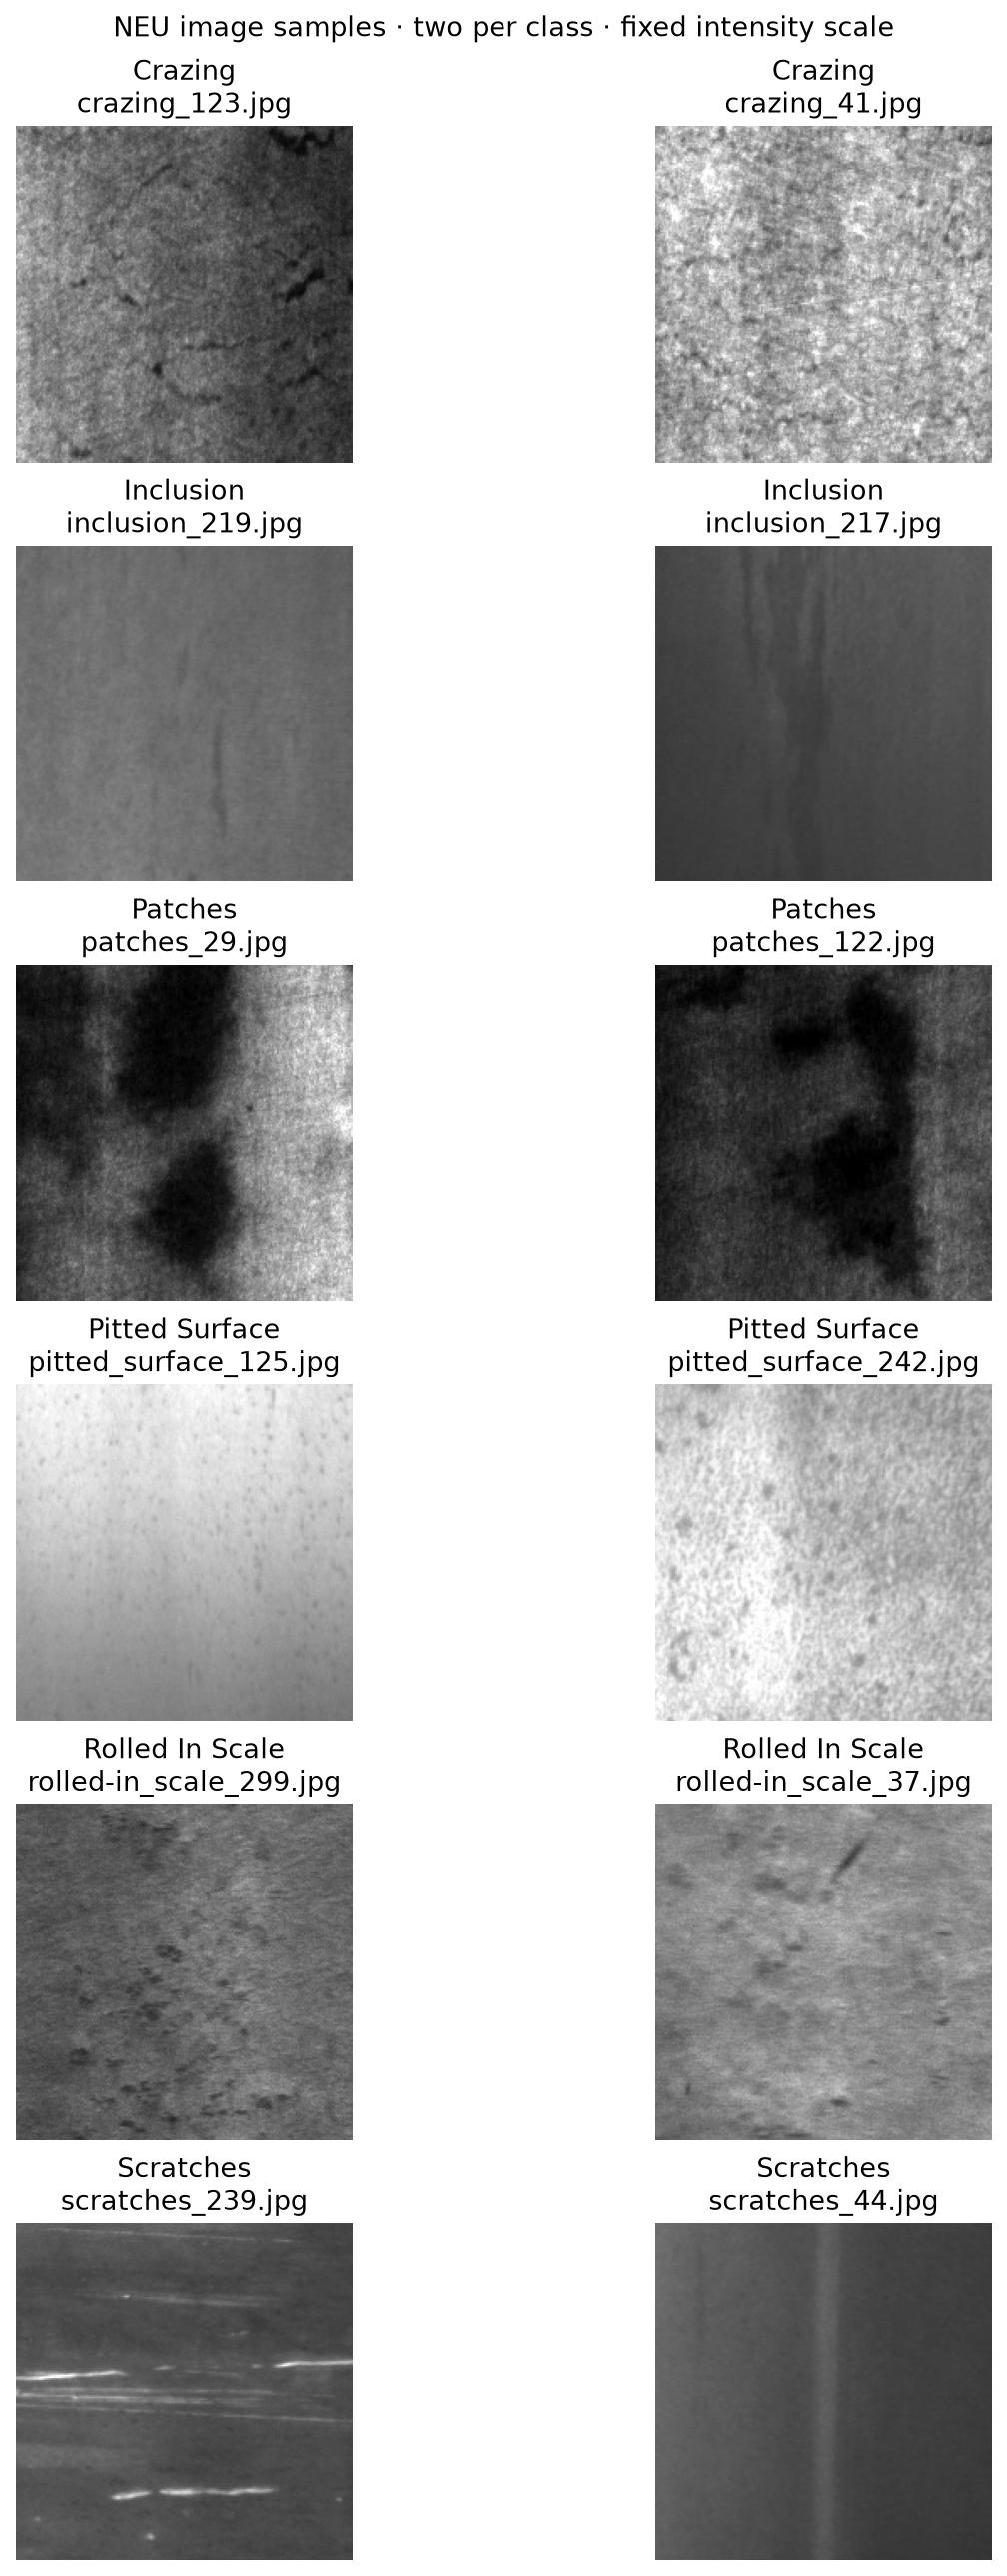

In [5]:
show_figure('outputs/figures/01_class_samples.png', 'Figure 1. Seeded examples from the original descriptive audit; two per class. Full-collection EDA preceded the split.', width=1050)

## 3. Locked split, shared validation and reporting design

After duplicate exclusion, the pooled source containers form 1,799 modelling images. A stratified **80/20 development/test split, seed 42**, gives 1,439 development images and 360 test images, with 60 test images per class. Persisted assignments and checksum locks are reused. A seed alone would not protect against silently changed data, ordering or library behaviour.

Both models use the same five stratified development folds, shuffled with seed 42. Each image is validation data once; the other folds supply training data. Scalers and CNN pixel normalisation are fitted on the current training fold only. After selection, each final model is refitted on all development images. Diagnostic tertiles are estimated from development, and stress severities and example-selection rules are fixed before the main test evaluation.

**Evaluation chronology.** The label and duplicate issues were resolved before modelling. HOG-SVM selection, CNN epoch selection and the controlled epoch-cap check used development only. The test set remained locked for model selection until the final frozen comparison. Earlier descriptive EDA had already covered the full collection: this is a model-selection holdout, not prospectively untouched external validation. Access guards and logs document particular executions; they are not a security guarantee about all prior inspection.

Accuracy is the fraction correct. For each class, precision is TP/(TP+FP), recall is TP/(TP+FN), and F1 is their harmonic mean. Macro scores average the six class scores equally, using zero for undefined scores. Report per-class values, confusion counts and row proportions alongside averages. Fold variation uses sample SD (ddof=1); overlapping training sets and selected checkpoints mean this is descriptive variation, not a confidence interval or nested-CV estimate. One seed per fold combines partition and initialisation effects without separating them.

In [6]:
development = manifest.loc[manifest.split.eq('development')]
test = manifest.loc[manifest.split.eq('test')].sort_values('path').reset_index(drop=True)
assert len(development) == 1439 and len(test) == 360
assert set(folds.path) == set(development.path) and folds.path.is_unique
assert set(folds.validation_fold) == set(range(5))
assert set(development.path).isdisjoint(test.path)
assert set(folds.sha256) == set(development.sha256)
fold_counts = pd.crosstab(folds.validation_fold, folds.class_name).reindex(columns=CLASSES)
fold_counts['validation_n'] = fold_counts.sum(axis=1)
fold_counts['training_n'] = len(development) - fold_counts.validation_n
display(Markdown('**Table 3. Shared validation-fold composition. Fold IDs are zero-based.**'))
display(fold_counts)

**Table 3. Shared validation-fold composition. Fold IDs are zero-based.**

class_name,crazing,inclusion,patches,pitted_surface,rolled_in_scale,scratches,validation_n,training_n
validation_fold,,,,,,,,
0,48,48,48,48,48,48,288,1151
1,48,48,48,48,48,48,288,1151
2,48,48,48,48,48,48,288,1151
3,48,48,48,48,48,48,288,1151
4,48,48,47,48,48,48,287,1152


## 4. HOG-SVM: a bounded handcrafted baseline

HOG encodes local gradient orientations [4]; an SVM learns class separation from these features [5]. Native 200 × 200 greyscale images are scaled to [0,1]. The fixed descriptor uses 9 orientation bins, 16 × 16 pixel cells, 2 × 2 cell blocks and L2-Hys normalisation, with no square-root transform. Its 4,356 features omit incomplete border cells: only 12 complete cells fit along each image side. The descriptor is a declared baseline, not a tuned optimum.

Six candidates combine linear/RBF kernels with C ∈ {0.1, 1, 10}; RBF gamma is `scale`. Each training fold fits a fresh StandardScaler and SVC. Deterministic per-image HOG extraction may precede CV because it learns no population statistics. There is no augmentation or PCA. Highest mean fold macro F1 selects the candidate; exact ties follow declared order, linear first and smaller C first. The selected **RBF, C=10, gamma=scale** pipeline is refitted on all development examples. Probability estimation is disabled; decision scores are not probabilities.

The bounded search makes the comparison auditable but does not establish the best possible HOG-SVM. All candidates below remain visible, including weaker settings. CV scores guided selection and therefore carry selection optimism.

In [7]:
show_table('outputs/experiments/03_hog_svm_20260923T232217_532748Z/cv_candidate_summary.csv', 'Table 4. All six HOG-SVM candidates; macro F1 determined selection.', columns=['kernel', 'C', 'gamma', 'accuracy_mean', 'f1_macro_mean', 'f1_macro_std'], index=False)

**Table 4. All six HOG-SVM candidates; macro F1 determined selection.**

kernel,C,gamma,accuracy_mean,f1_macro_mean,f1_macro_std
rbf,10.000000,scale,0.888804,0.887114,0.012463
rbf,1.000000,scale,0.879769,0.877231,0.011219
linear,0.100000,scale,0.833909,0.831926,0.011481
linear,1.000000,scale,0.833909,0.831926,0.011481
linear,10.000000,scale,0.833909,0.831926,0.011481
rbf,0.100000,scale,0.731734,0.709126,0.038219


## 5. Compact CNN: learning within a CPU budget

The CNN learns image representations through supervised optimisation, contrasting with the fixed HOG representation [6]. One architecture and one training configuration were declared, with no pretrained weights or external training data.

| Component | Frozen specification and rationale |
| --- | --- |
| Input | One 200 × 200 greyscale channel, scaled to [0,1], then standardised using training-fold pixel mean and SD. |
| Feature extractor | Three 3 × 3 convolutions, without bias, with 8, 16 and 32 channels; BatchNorm, non-inplace ReLU and 2 × 2 max pooling after each. First convolution stride 2, later strides 1; padding 1 throughout. |
| Head | Adaptive average pooling, dropout 0.25 and a 32-to-6 linear layer returning logits. Total: 6,142 trainable parameters. |
| Optimisation | Cross-entropy loss; AdamW; learning rate 0.001; weight decay 0.0001; batch size 32, retaining the incomplete final batch. No scheduler or augmentation. |
| Selection | Maximum 25 epochs; five epochs of patience without strictly higher validation macro F1; earliest checkpoint wins exact ties. Validation loss is diagnostic only. |
| Repeatability | Fresh weights and optimiser per fold; seeds 42 + zero-based fold ID; deterministic algorithms; four CPU threads; zero loader workers. |
| Final fit | Fresh model on all 1,439 development images, for the ceiling of the median selected epoch: 20 epochs. No test-based early stopping. |

Striding, pooling and the small head reduce computation but can discard fine texture and spatial arrangement. No augmentation is assumed valid for industrial defect meaning. BatchNorm statistics update only in training; evaluation disables dropout. End-of-epoch training and validation curves use the same weights in evaluation mode, making their comparison more interpretable than comparing online training loss directly with validation loss.

Six SVM configurations and CNN validation-epoch selection are different search procedures. Differences cannot be attributed solely to representation learning: optimisation, capacity and regularisation also differ. The median-epoch final-fit rule is a practical approximation, not a proven optimum for the larger development set.

In [8]:
display(Markdown('**Table 5. Development means and sample fold SDs for the exact frozen model runs.**'))
development_summary = pd.DataFrame([
    {'model': name, 'metric': metric, 'mean': result['cv_mean'][metric], 'fold_sd': result['cv_std'][metric]}
    for name, result in [('HOG-SVM', svm_result), ('CNN', cnn_result)] for metric in METRICS
])
display(development_summary)
display(Markdown(f"CNN development macro F1 exceeds HOG-SVM by **{cnn_result['development_mean_f1_difference_vs_svm']:+.6f}**. This is a selected development comparison, not an independent test result."))

**Table 5. Development means and sample fold SDs for the exact frozen model runs.**

,model,metric,mean,fold_sd
0,HOG-SVM,accuracy,0.888804,0.012121
1,HOG-SVM,precision_macro,0.891109,0.011046
2,HOG-SVM,recall_macro,0.888697,0.012242
3,HOG-SVM,f1_macro,0.887114,0.012463
4,CNN,accuracy,0.937464,0.028826
5,CNN,precision_macro,0.941295,0.026107
6,CNN,recall_macro,0.937500,0.028842
7,CNN,f1_macro,0.937747,0.028422


CNN development macro F1 exceeds HOG-SVM by **+0.050634**. This is a selected development comparison, not an independent test result.

In [9]:
show_table('outputs/experiments/04_cnn_20260925T222923_890724Z/fold_metrics.csv', 'Table 6. CNN selected validation checkpoints and completed epochs.', columns=['fold', 'seed', 'best_epoch', 'epochs_run', 'stop_reason', 'f1_macro'], index=False)

**Table 6. CNN selected validation checkpoints and completed epochs.**

fold,seed,best_epoch,epochs_run,stop_reason,f1_macro
0,42,20,25,patience,0.965152
1,43,15,20,patience,0.927876
2,44,8,13,patience,0.893120
3,45,23,25,epoch_limit,0.954774
4,46,23,25,epoch_limit,0.947815


**Figure 2. Saved CNN fold learning curves. The epoch ceiling motivates a controlled adequacy check.**

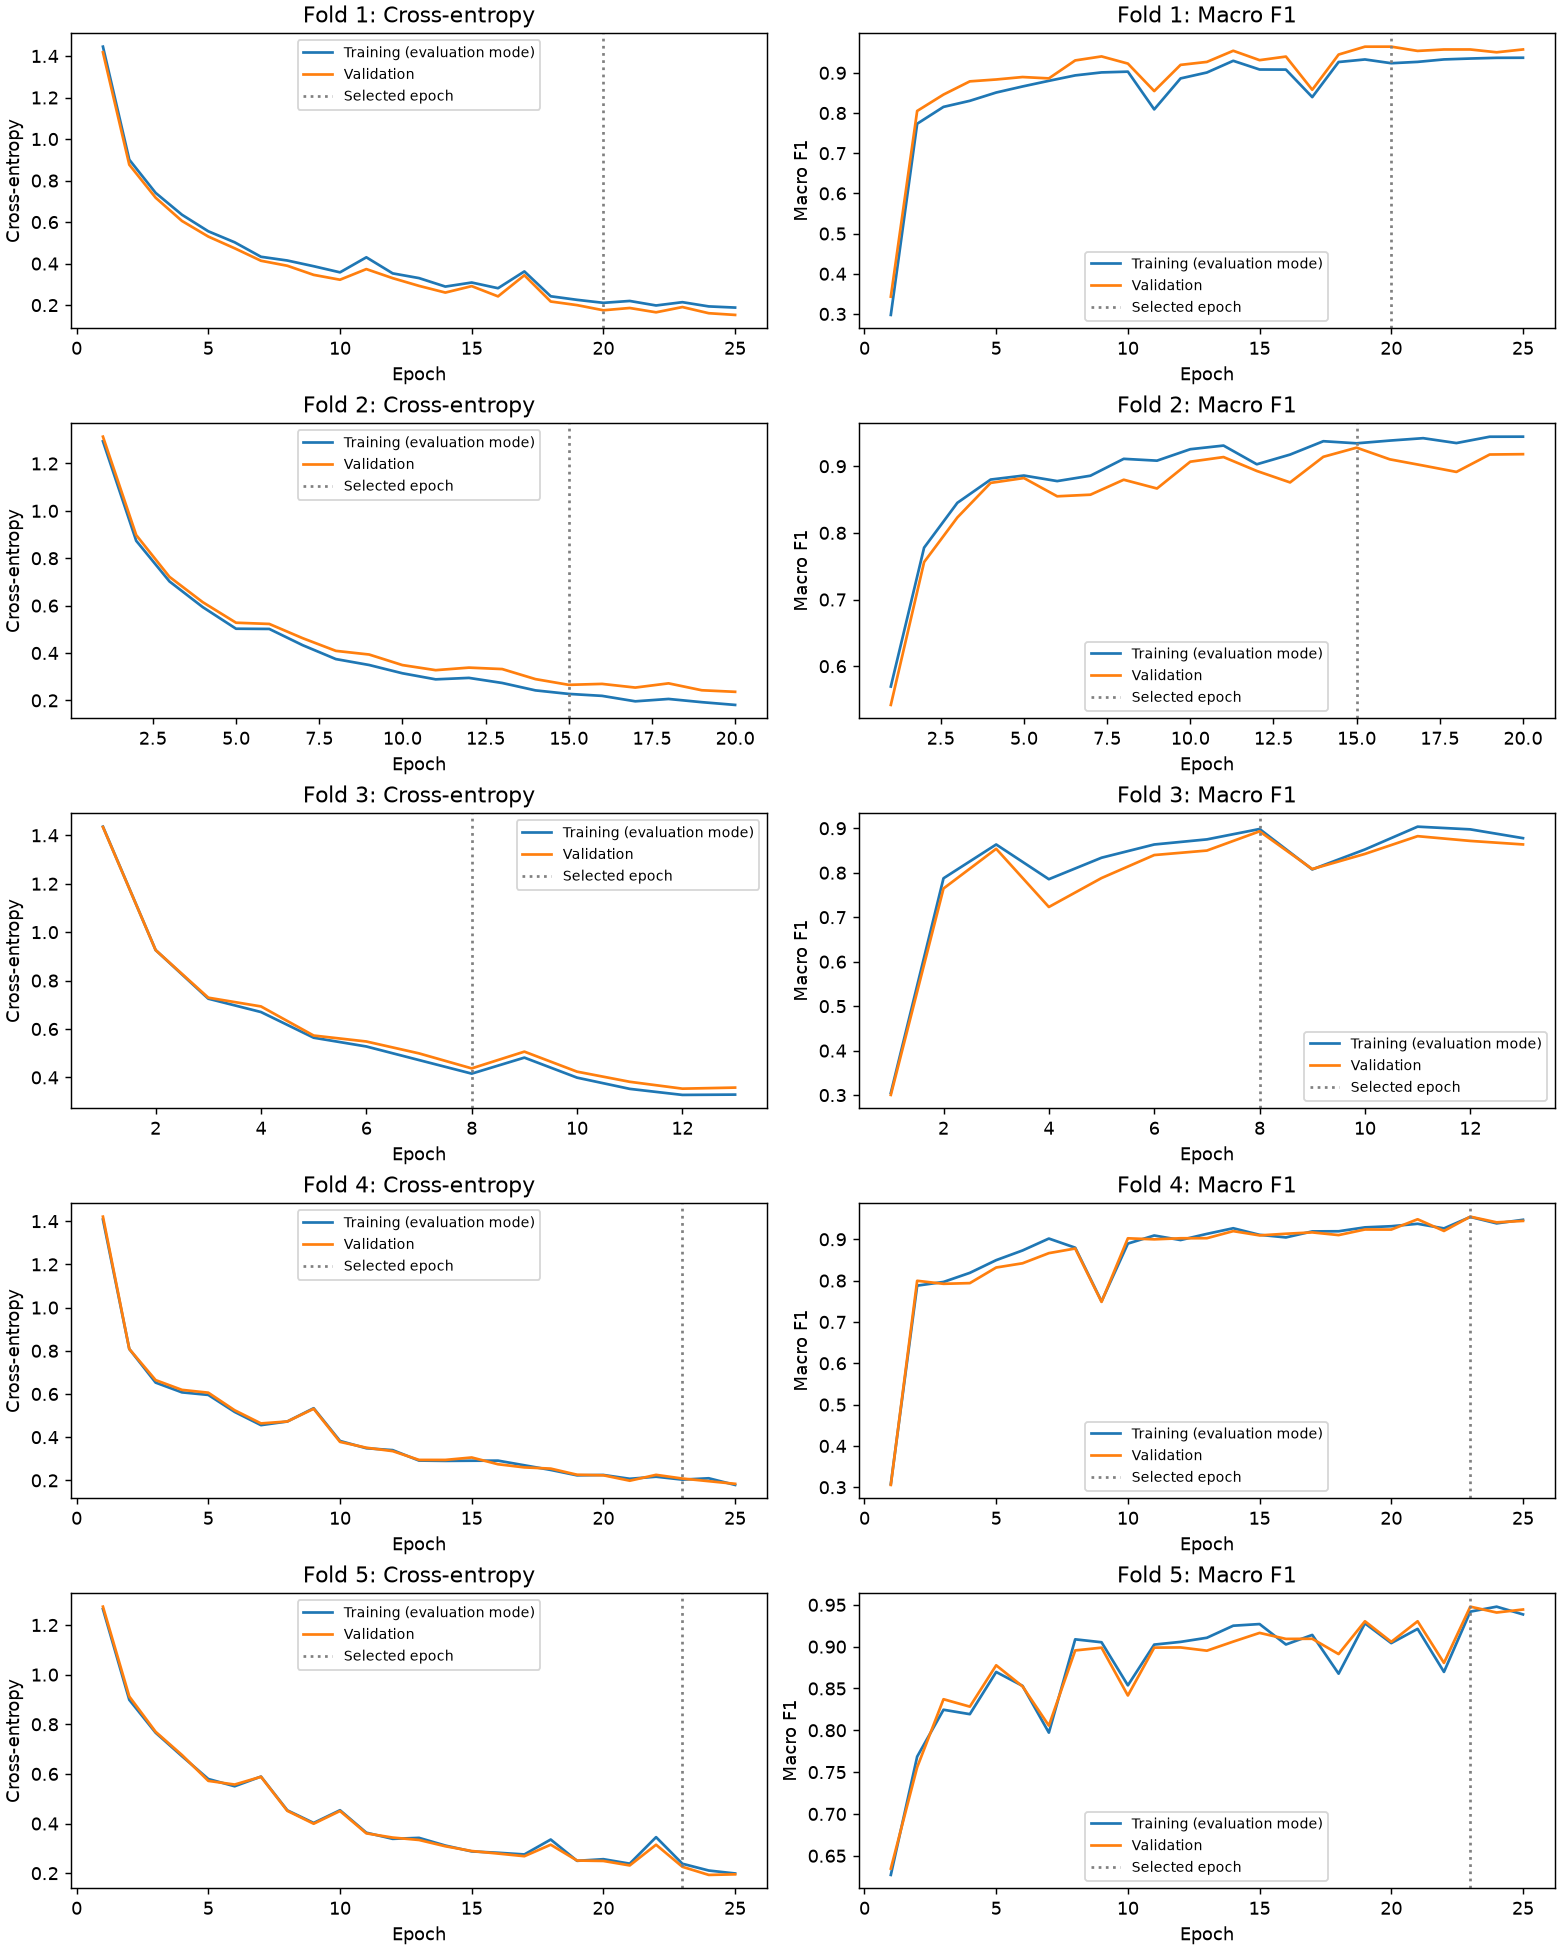

In [10]:
show_figure('outputs/experiments/04_cnn_20260925T222923_890724Z/fold_learning_curves.png', 'Figure 2. Saved CNN fold learning curves. The epoch ceiling motivates a controlled adequacy check.', width=1050)

## 6. Epoch-cap sensitivity: retain 25 epochs

Three baseline folds reached epoch 25, but one also satisfied patience there; only two were stopped solely by the ceiling. Notebook 04a changed only the maximum cap from 25 to 40, preserving folds, seeds, model, preprocessing, optimiser and the strict macro-F1 stopping rule. All five folds restarted, with no test access and no replacement final checkpoint.

The predeclared rule adopted 40 only if at least two previously ceiling-truncated folds improved by at least 0.005 and selected epochs beyond 25. It retained 25 as adequate if the absolute mean change was at most 0.002, no fold improved by at least 0.005 and at least three folds stopped by patience before 40. Other outcomes retained 25 provisionally as inconclusive. These are pragmatic thresholds, not significance levels. Failure to reproduce the common prefix within 1e-10 or an environment mismatch would prevent automatic revision.

The recorded environments matched and all 108 shared epochs reproduced within 1.12e-16. Selected epochs stayed [20, 15, 8, 23, 23]. Under the 40-epoch ceiling, all folds stopped by patience at [25, 20, 13, 28, 28]; none reached 40. Mean macro F1 was 0.937747 under either cap; the saved mean paired difference of -2.220446e-17 is numerical round-off. Folds 4 and 5 each added three epochs without surpassing their selected epoch-23 score.

**Decision: retain the 25-epoch maximum and the existing 20-epoch final refit.** The adequacy rule is satisfied for this stopping policy. This is neither statistical equivalence nor proof of global convergence. Validation-loss improvements need not change the selected macro F1; loss never controlled checkpointing. The check arose from observed development behaviour and adds selection optimism. No additional caps or retuning followed.

In [11]:
show_table('outputs/experiments/04a_cnn_epoch_sensitivity_20260926T000504_973861Z/paired_25_vs_40_fold_results.csv', 'Table 7. Paired epoch-budget evidence; fold_display uses one-based numbering.', columns=['fold_display', 'best_epoch_25', 'epochs_run_25', 'best_epoch_40', 'epochs_run_40', 'f1_macro_25', 'f1_macro_40', 'delta_f1_macro', 'measured_post25_compute_seconds'], index=False)

**Table 7. Paired epoch-budget evidence; fold_display uses one-based numbering.**

fold_display,best_epoch_25,epochs_run_25,best_epoch_40,epochs_run_40,f1_macro_25,f1_macro_40,delta_f1_macro,measured_post25_compute_seconds
1,20,25,20,25,0.965152,0.965152,0.000000,0.000000
2,15,20,15,20,0.927876,0.927876,-0.000000,0.000000
3,8,13,8,13,0.893120,0.893120,0.000000,0.000000
4,23,25,23,28,0.954774,0.954774,-0.000000,18.995149
5,23,25,23,28,0.947815,0.947815,0.000000,19.390605


**Figure 3. Paired validation trajectories. Loss and macro F1 answer different questions.**

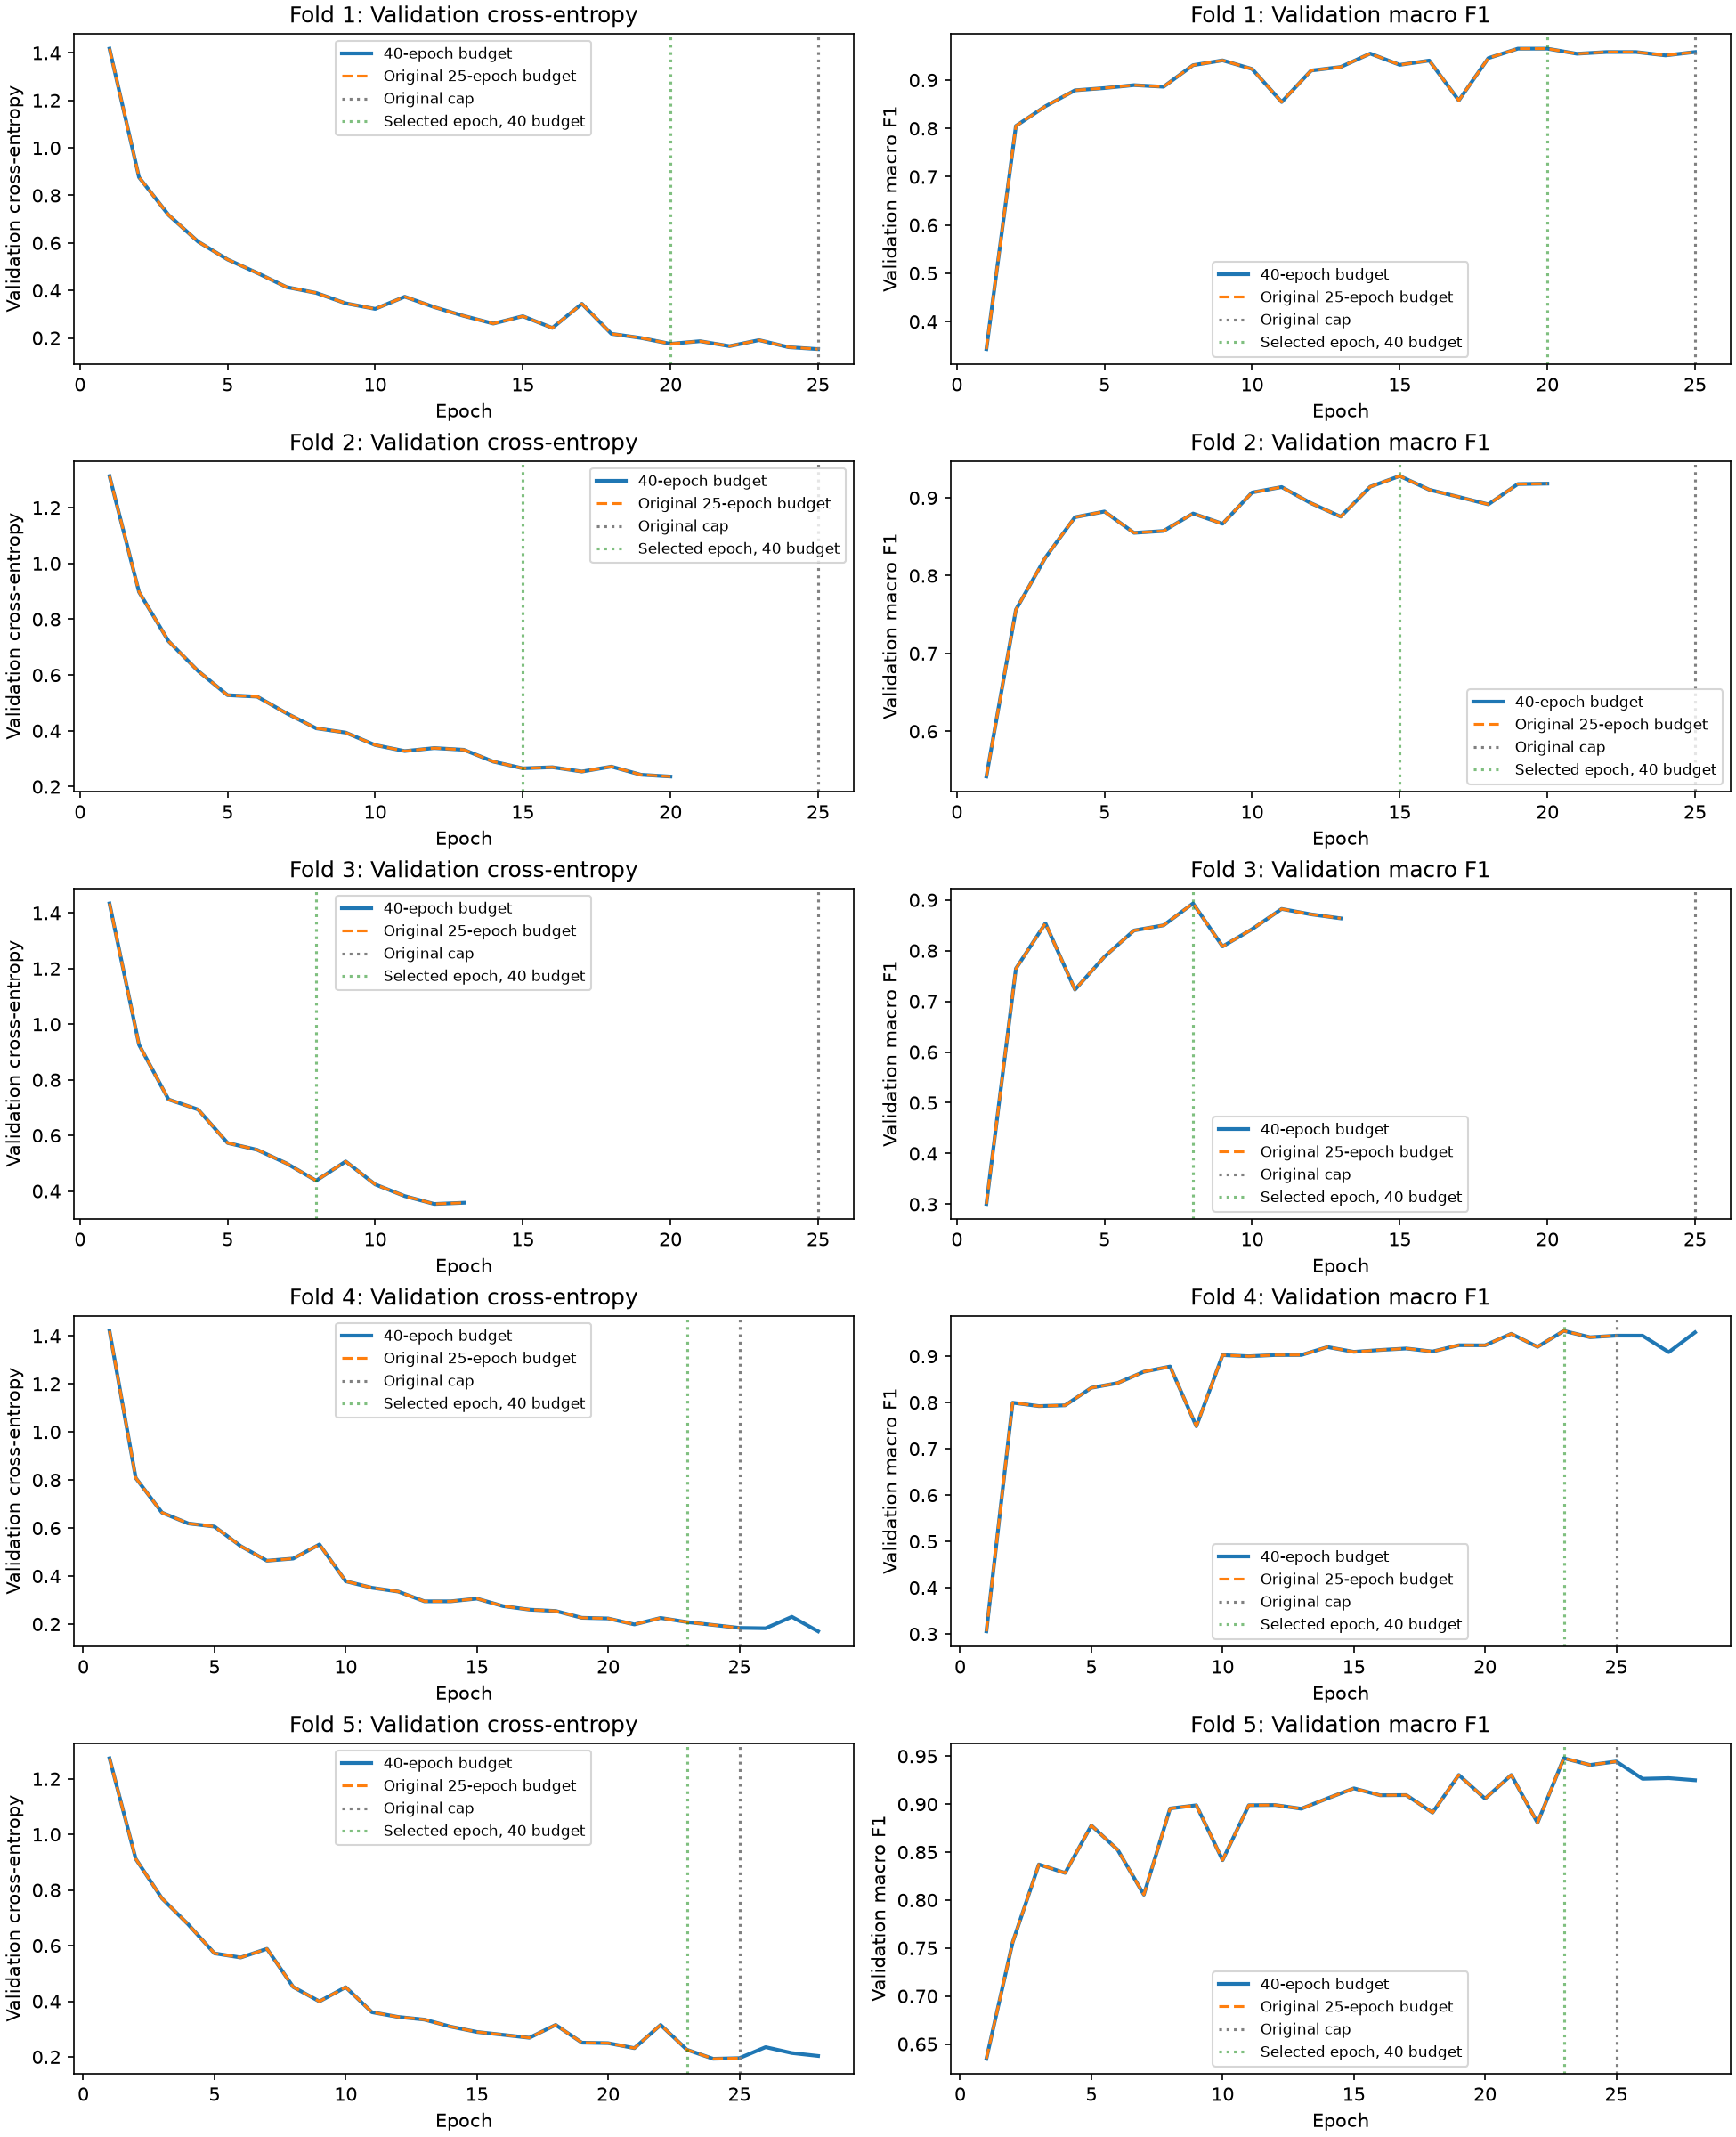

In [12]:
show_figure('outputs/experiments/04a_cnn_epoch_sensitivity_20260926T000504_973861Z/validation_loss_f1_25_vs_40.png', 'Figure 3. Paired validation trajectories. Loss and macro F1 answer different questions.', width=1050)

The saved baseline CV wall time is 712.73 seconds and sensitivity CV wall time is 741.73 seconds, a historical difference of 29.00 seconds. The six additional epochs account for 38.39 seconds measured within the sensitivity run, including optimisation and diagnostic passes but excluding checkpoint I/O. Machine-load differences prevent treating historical subtraction as the isolated cost of extending the cap.

## 7. Final locked-test comparison

Both frozen models were evaluated on the same 360 test images after development decisions were complete. A committed prediction cache and a single-evaluation receipt preserve that boundary. This notebook verifies and reuses them. It does not delete start markers or generate fresh predictions. Stress, attribution and timing analyses are distinct from the main clean evaluation.

The following independent readback recalculates accuracy, macro precision, recall and F1 from saved labels and predictions, checks per-class metrics and both confusion matrices, and compares them with the frozen tables. Float comparisons allow only numerical round-off. Nothing is written back to the source evidence.

In [13]:
predictions = read_table(FINAL_RUN + '/tables/clean_predictions.csv')
clean = read_table(FINAL_RUN + '/tables/clean_metrics.csv').set_index('model')
per_class = read_table(FINAL_RUN + '/tables/per_class_metrics.csv')
receipt = read_json(FINAL_RUN + '/cache/clean_receipt.json')
assert receipt['status'] == 'COMMITTED' and receipt['main_evaluation_count'] == 1
assert sha(ROOT / FINAL_RUN / 'cache/clean_predictions.npz') == receipt['cache_sha256']
assert sha(ROOT / FINAL_RUN / 'reports/predeclared_protocol.json') == receipt['protocol_sha256'] == final_result['protocol_sha256']
assert predictions.path.tolist() == test.path.tolist() == protocol['test_path_order']
assert predictions.class_name.tolist() == test.class_name.tolist()
assert predictions.sha256.tolist() == test.sha256.tolist()

def metric_values(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=CLASSES, average='macro', zero_division=0)
    return np.array([accuracy_score(y_true, y_pred), p, r, f])

for model, column, stem in [('HOG-SVM', 'svm_predicted', 'hog-svm'), ('CNN', 'cnn_predicted', 'cnn')]:
    y_true, y_pred = predictions.class_name, predictions[column]
    np.testing.assert_allclose(metric_values(y_true, y_pred), clean.loc[model, METRICS].to_numpy(float), atol=1e-12, rtol=0)
    p, r, f, n = precision_recall_fscore_support(y_true, y_pred, labels=CLASSES, zero_division=0)
    frozen = per_class.loc[per_class.model.eq(model)].set_index('class').loc[CLASSES]
    np.testing.assert_allclose(np.column_stack([p, r, f, n]), frozen[['precision','recall','f1-score','support']], atol=1e-12, rtol=0)
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    saved_cm = read_table(FINAL_RUN + f'/tables/{stem}_confusion_counts.csv', index_col=0)
    np.testing.assert_array_equal(cm, saved_cm.to_numpy())
    saved_proportions = read_table(FINAL_RUN + f'/tables/{stem}_confusion_row_proportions.csv', index_col=0)
    np.testing.assert_allclose(cm / cm.sum(axis=1, keepdims=True), saved_proportions, atol=1e-12, rtol=0)
    recorded = next(item for item in final_result['clean_metrics'] if item['model'] == model)
    np.testing.assert_allclose(clean.loc[model, METRICS].to_numpy(float), [recorded[m] for m in METRICS], atol=1e-12, rtol=0)
display(Markdown('**Table 8. Frozen locked-test metrics, independently checked from saved predictions.**'))
display(clean.style.format('{:.6f}'))
delta = clean.loc['CNN', 'f1_macro'] - clean.loc['HOG-SVM', 'f1_macro']
display(Markdown(f"CNN accuracy is **{clean.loc['CNN','accuracy']:.4f}**, versus **{clean.loc['HOG-SVM','accuracy']:.4f}** for HOG-SVM. The macro-F1 difference is **{delta:+.6f}**, or **{100*delta:.4f} percentage points**."))

**Table 8. Frozen locked-test metrics, independently checked from saved predictions.**

,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
HOG-SVM,0.902778,0.905498,0.902778,0.902302
CNN,0.955556,0.961108,0.955556,0.955493


CNN accuracy is **0.9556**, versus **0.9028** for HOG-SVM. The macro-F1 difference is **+0.053191**, or **5.3191 percentage points**.

In [14]:
show_table('outputs/experiments/05_comparison_xai_robustness/tables/per_class_metrics.csv', 'Table 9. Locked-test per-class precision, recall, F1 and support.', columns=None, index=False)

**Table 9. Locked-test per-class precision, recall, F1 and support.**

model,class,precision,recall,f1-score,support
HOG-SVM,crazing,0.921875,0.983333,0.951613,60.000000
HOG-SVM,inclusion,0.800000,0.933333,0.861538,60.000000
HOG-SVM,patches,0.905660,0.800000,0.849558,60.000000
HOG-SVM,pitted_surface,0.894737,0.850000,0.871795,60.000000
HOG-SVM,rolled_in_scale,1.000000,1.000000,1.000000,60.000000
HOG-SVM,scratches,0.910714,0.850000,0.879310,60.000000
CNN,crazing,0.983051,0.966667,0.974790,60.000000
CNN,inclusion,0.833333,1.000000,0.909091,60.000000
CNN,patches,0.967213,0.983333,0.975207,60.000000
CNN,pitted_surface,1.000000,0.816667,0.899083,60.000000


**Figure 4. Clean-test confusion counts and row proportions for both frozen models.**

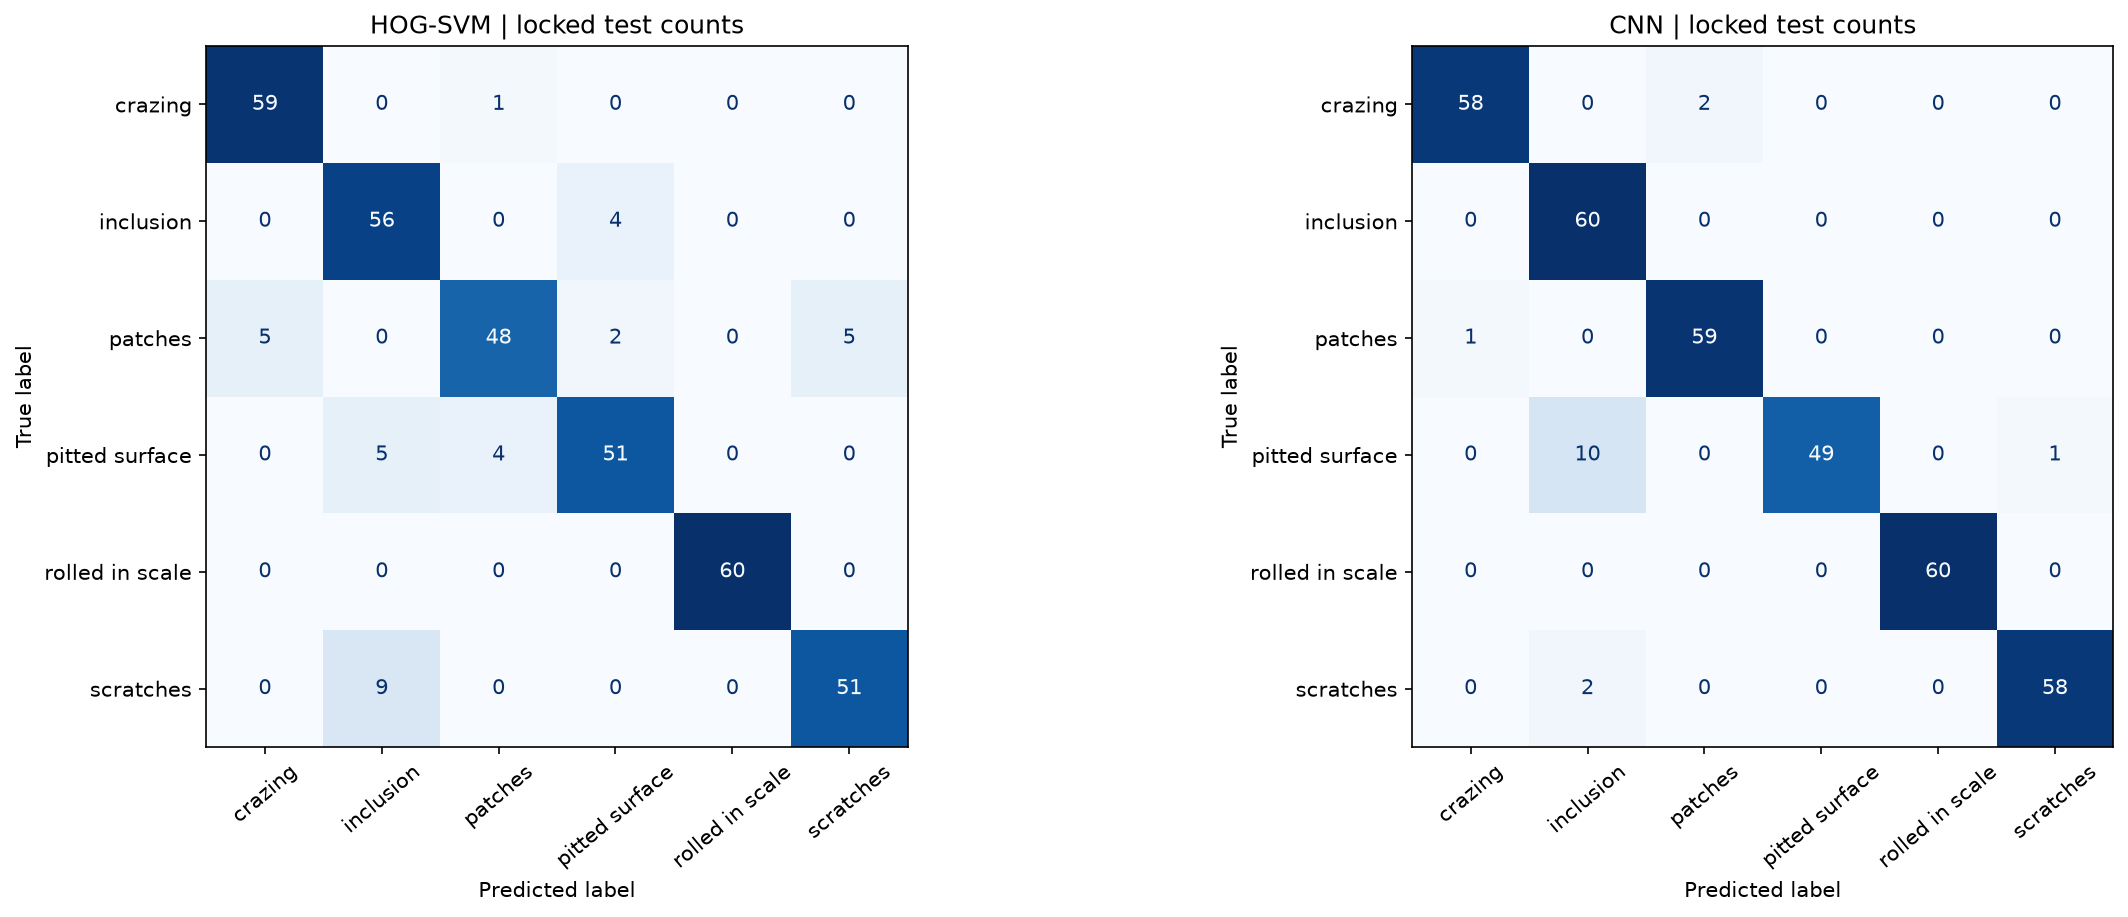

In [15]:
show_figure('outputs/experiments/05_comparison_xai_robustness/figures/clean_confusion_matrices.png', 'Figure 4. Clean-test confusion counts and row proportions for both frozen models.', width=1150)

### Reading the clean comparison critically

The aggregate gain is not uniform across defect categories. CNN pitted-surface recall is 0.8167, compared with 0.8500 for HOG-SVM. The CNN confusion matrix records 10 pitted-surface images predicted as inclusion. Conversely, patches recall is 0.9833 for CNN versus 0.8000 for HOG-SVM. An application where confusing pitting with inclusion is particularly costly could judge this trade-off differently from macro F1. No cost weighting is invented or selected from these test results.

## 8. Paired errors and conditional uncertainty

The two predictions are paired by image. Correctness overlap is more informative than two isolated accuracy values: it distinguishes shared failures from errors that differ between representations. The high-confidence error table uses the CNN's uncalibrated softmax score. The SVM was frozen with probability estimation disabled; its decision scores are not substituted for probabilities and no calibration is fitted after test access. See the [SVC documentation](https://scikit-learn.org/dev/modules/generated/sklearn.svm.SVC.html).

A predeclared paired stratified bootstrap resamples image indices within each true class, applying each resample to both models. Percentile intervals describe uncertainty conditional on this sample, class balance and frozen fitted models. Unknown acquisition dependence, model-selection variability and domain shift are not captured. The intervals are exploratory, without multiplicity adjustment or a universal superiority claim.

In [16]:
svm_correct = predictions.svm_predicted.eq(predictions.class_name)
cnn_correct = predictions.cnn_predicted.eq(predictions.class_name)
categories = np.select([svm_correct & cnn_correct, svm_correct & ~cnn_correct,
                        ~svm_correct & cnn_correct], ['both_correct','svm_correct_cnn_wrong','cnn_correct_svm_wrong'], default='both_wrong')
observed = pd.Series(categories).value_counts().to_dict()
assert observed == final_result['disagreement_counts']
assert sum(observed.values()) == 360
display(Markdown('**Table 10. Paired correctness on identical test images.**'))
display(pd.DataFrame({'category': list(final_result['disagreement_counts']), 'images': list(final_result['disagreement_counts'].values())}))
highest_error = predictions.loc[~cnn_correct].sort_values('cnn_max_softmax', ascending=False).iloc[0]
high_errors = predictions.loc[~cnn_correct & predictions.cnn_max_softmax.ge(protocol['high_confidence_softmax_threshold'])]
assert len(high_errors) == final_result['high_softmax_errors'] == 0
display(Markdown(f"The CNN alone is correct on **{observed['cnn_correct_svm_wrong']}** images; HOG-SVM alone on **{observed['svm_correct_cnn_wrong']}**. Both fail on **{observed['both_wrong']}**. The highest CNN softmax among errors is **{highest_error.cnn_max_softmax:.6f}**, below the predeclared 0.90 threshold. Absence of errors above this threshold in this sample does not establish calibration."))
draws = read_table(FINAL_RUN + '/tables/paired_bootstrap_draws.csv')
intervals = read_table(FINAL_RUN + '/tables/paired_bootstrap_intervals.csv')
assert len(draws) == 2000
for row in intervals.itertuples():
    np.testing.assert_allclose(np.quantile(draws[row.metric], [.025, .975]), [row.lower_95, row.upper_95], atol=1e-12, rtol=0)
display(Markdown('**Table 11. CNN minus HOG-SVM: saved paired stratified 95% percentile intervals, checked against all 2,000 saved draws (seed 42).**'))
display(intervals)
display(Markdown('The positive intervals support a conditional clean-sample advantage. They do not incorporate model-selection variation, acquisition dependence or external shift. No significance or universal-superiority claim follows.'))

**Table 10. Paired correctness on identical test images.**

,category,images
0,both_correct,315
1,svm_correct_cnn_wrong,10
2,cnn_correct_svm_wrong,29
3,both_wrong,6


The CNN alone is correct on **29** images; HOG-SVM alone on **10**. Both fail on **6**. The highest CNN softmax among errors is **0.865220**, below the predeclared 0.90 threshold. Absence of errors above this threshold in this sample does not establish calibration.

**Table 11. CNN minus HOG-SVM: saved paired stratified 95% percentile intervals, checked against all 2,000 saved draws (seed 42).**

,metric,estimate,lower_95,upper_95
0,delta_accuracy,0.052778,0.019444,0.086111
1,delta_macro_f1,0.053191,0.019844,0.086526


The positive intervals support a conditional clean-sample advantage. They do not incorporate model-selection variation, acquisition dependence or external shift. No significance or universal-superiority claim follows.

In [17]:
shared_errors = read_table(FINAL_RUN + '/tables/disagreements_both_wrong.csv')
shared_errors['filename'] = shared_errors.path.map(lambda value: Path(value).name)
display(Markdown('**Table 12. Shared failures, retained for targeted review; filenames identify the saved examples.**'))
display(shared_errors[['filename','class_name','svm_predicted','cnn_predicted','cnn_max_softmax']])

**Table 12. Shared failures, retained for targeted review; filenames identify the saved examples.**

,filename,class_name,svm_predicted,cnn_predicted,cnn_max_softmax
0,patches_14.jpg,patches,crazing,crazing,0.543143
1,pitted_surface_10.jpg,pitted_surface,inclusion,inclusion,0.808938
2,pitted_surface_102.jpg,pitted_surface,patches,scratches,0.461347
3,pitted_surface_108.jpg,pitted_surface,inclusion,inclusion,0.809533
4,scratches_69.jpg,scratches,inclusion,inclusion,0.865220
5,scratches_73.jpg,scratches,inclusion,inclusion,0.477808


## 9. Grad-CAM and the HOG representation

[Captum LayerGradCam](https://captum.ai/api/layer.html) attributes a selected output to a convolutional layer. Here the target is a class **logit**, the layer is `conv3`, and `relu_attributions=True` keeps positive contributions. Maps are 25 by 25 before bilinear upsampling to 200 by 200. Predicted-class and true-class targets are shown side by side, including when they coincide. Each panel is independently scaled to [0,1] for display; raw maps and extrema are saved, and colour intensity cannot be compared between panels. An all-zero positive map remains zero.

The selection rule deliberately spans error types rather than choosing visually persuasive maps. It is illustrative and outcome-conditioned, not representative sampling. No localisation masks, expert annotation, randomisation checks or causal intervention validate these explanations. Upsampling creates no new spatial evidence, and a plausible hotspot is not proof that the network recognises a physical defect. The original [Grad-CAM paper](https://arxiv.org/abs/1610.02391) describes the method; the limits of this implementation remain material.

HOG panels show local gradient structure used by the descriptor. They are **representation visualisations, not prediction attribution** for the nonlinear SVM. Incomplete border cells are omitted by the frozen descriptor.

Grad-CAM is grounded in Selvaraju et al. [7], with the implementation using Captum [10]. The distinction between visual plausibility and validated model sensitivity is supported by saliency sanity-check research [8]. Such checks were not performed here; citing them does not validate these maps. Cases were selected by the first sorted path in each joint correctness category, the highest-softmax CNN error and the first CNN-correct path, with duplicates removed.

**Figure 5. Frozen illustrative cases: original image, target-specific CNN maps and HOG representation. Each heatmap is independently scaled.**

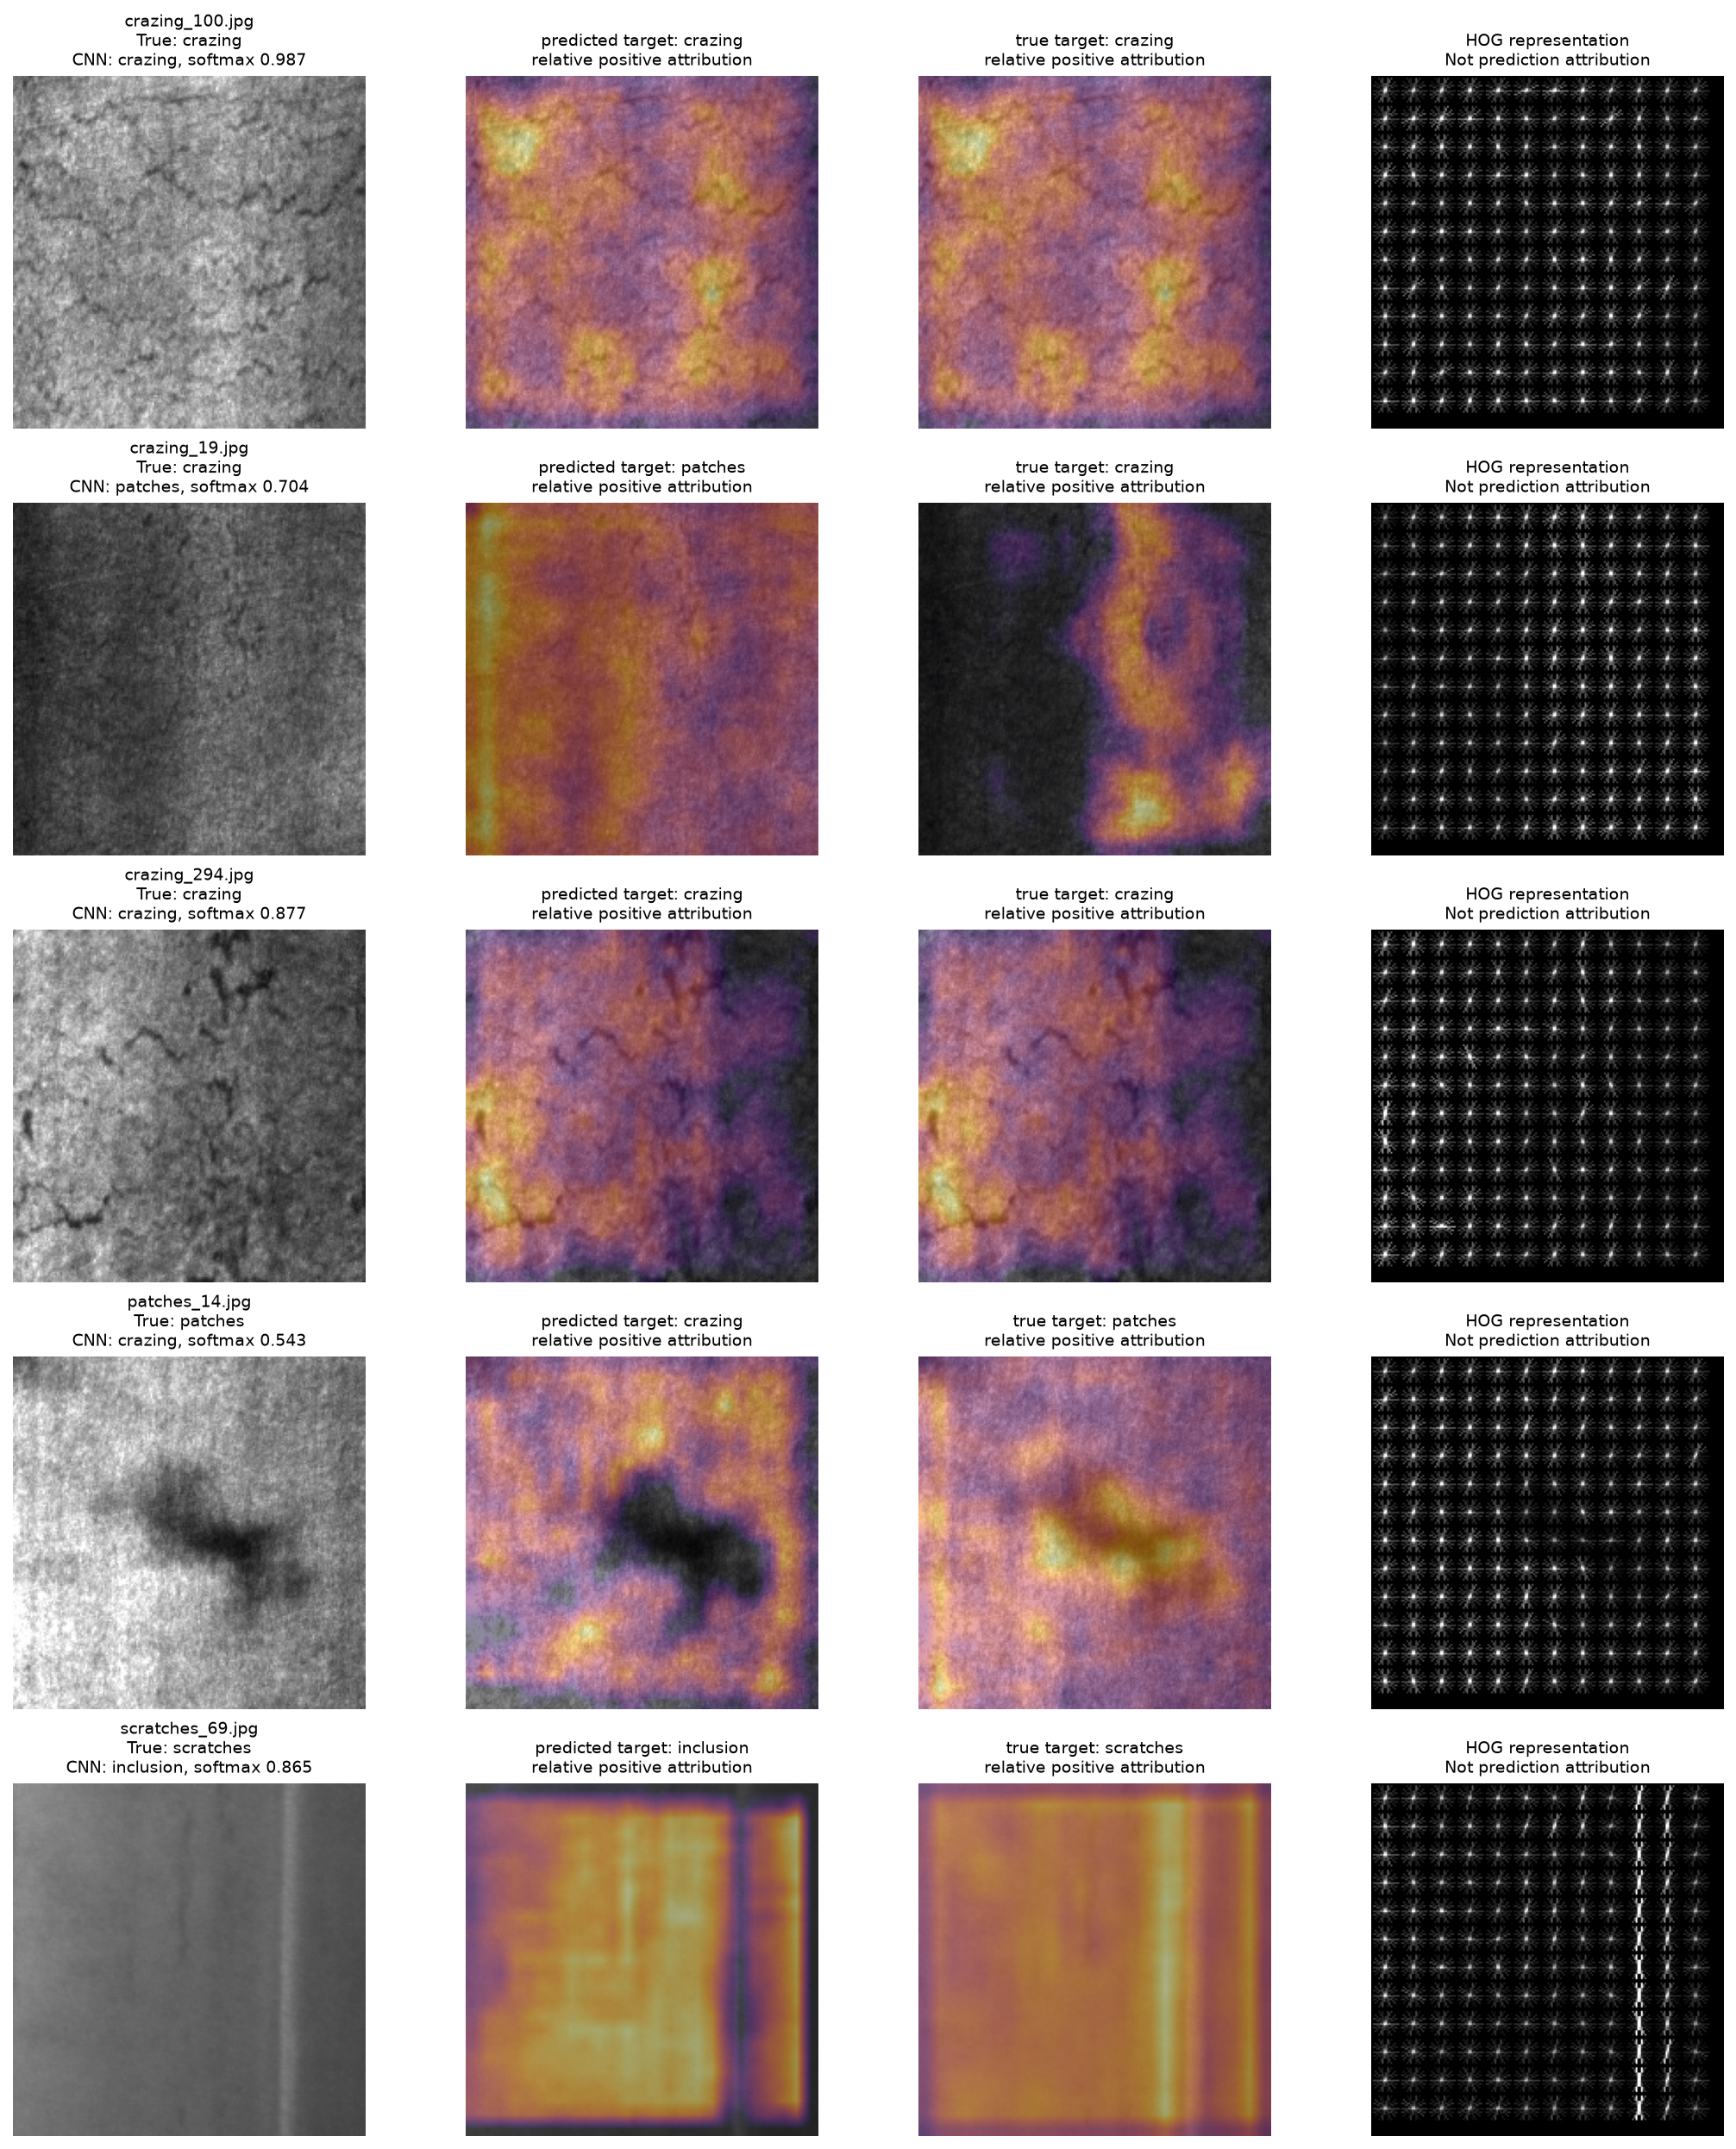

In [18]:
show_figure('outputs/experiments/05_comparison_xai_robustness/figures/gradcam_and_hog_cases.png', 'Figure 5. Frozen illustrative cases: original image, target-specific CNN maps and HOG representation. Each heatmap is independently scaled.', width=1150)

### Interpretation of the displayed cases

In `crazing_100.jpg`, the predicted and true targets coincide and the maps are identical, as expected. Stronger responses occur in several regions of the textured image; the map does not trace a validated defect boundary. For `crazing_19.jpg`, the incorrect patches target has a broad positive response, while the crazing target is more concentrated on the right. This difference is target-dependent evidence, not proof that a particular feature caused the error.

For `patches_14.jpg`, the true patches map includes the prominent central dark region, while the predicted crazing map places relatively greater weight around it. The image is nevertheless misclassified. A visually plausible true-class map therefore does not imply that the corresponding class wins the model's decision. In `scratches_69.jpg`, both targets have broad responses and different emphasis near the vertical structure. The highest-softmax CNN error has a score of approximately 0.865, below the predeclared 0.90 threshold. There are no errors meeting that threshold in this sample; this does not establish calibration or justify a production confidence threshold.

Three of the five selected images are crazing examples because class-prefixed filenames affect the first-path rule. The rule avoids discretionary visual cherry-picking but sacrifices class coverage. These cases cannot characterise explanations across all six classes. HOG panels show gradient structure only; their appearance cannot explain the SVM's individual decisions.

## 10. Diagnostic image-condition subgroups

The thresholds are fixed from development and applied unchanged to clean test properties. Reported macro F1 always averages the same six classes, including zero for undefined class scores, and the class counts accompany every subgroup. Small or missing classes can depress this metric and make comparisons unstable. Within-class recalls help distinguish composition effects from condition effects but do not remove confounding. Multiple overlapping exploratory comparisons are not causal tests or demographic fairness evidence.

Brightness is mean 8-bit intensity; contrast is its population SD; sharpness is the variance of the four-neighbour interior Laplacian, `up + down + left + right - 4 × centre`. The last responds to noise and texture as well as focus. Global development tertiles define low (≤q1), middle (>q1 and ≤q2) and high (>q2); thresholds are applied unchanged to test properties.

In [19]:
show_table('outputs/experiments/05_comparison_xai_robustness/tables/subgroup_thresholds.csv', 'Table 13. Development-only tertile thresholds on the original 0 to 255 intensity scale.', columns=None, index=True)

**Table 13. Development-only tertile thresholds on the original 0 to 255 intensity scale.**

,q1,q2
brightness,105.161075,144.481150
contrast,17.435556,28.747704
sharpness,115.177590,894.144769


In [20]:
subgroups = read_table(FINAL_RUN + '/tables/diagnostic_subgroup_metrics.csv')
properties = read_table(FINAL_RUN + '/tables/test_image_properties.csv').set_index('path').loc[predictions.path]
development_properties = read_table(FINAL_RUN + '/tables/development_image_properties.csv')
assert set(development_properties.path) == set(development.path)
for prop, thresholds in protocol['thresholds'].items():
    np.testing.assert_allclose(development_properties[prop].quantile([1/3, 2/3]), thresholds, atol=1e-10, rtol=0)
    bins = np.where(properties[prop].to_numpy() <= thresholds[0], 'low', np.where(properties[prop].to_numpy() <= thresholds[1], 'middle', 'high'))
    for group in ['low', 'middle', 'high']:
        mask = bins == group
        for model, column in [('HOG-SVM','svm_predicted'), ('CNN','cnn_predicted')]:
            row = subgroups.loc[subgroups.property.eq(prop) & subgroups.bin.eq(group) & subgroups.model.eq(model)].iloc[0]
            assert row.n == int(mask.sum())
            np.testing.assert_allclose(metric_values(predictions.class_name[mask], predictions[column][mask]), row[METRICS].to_numpy(float), atol=1e-12, rtol=0)
display(Markdown('**Table 14. Fixed-six-class subgroup metrics, verified from saved clean predictions.**'))
display(subgroups[['property','bin','n','model','accuracy','f1_macro']])

**Table 14. Fixed-six-class subgroup metrics, verified from saved clean predictions.**

,property,bin,n,model,accuracy,f1_macro
0,brightness,low,121,HOG-SVM,0.917355,0.904302
1,brightness,low,121,CNN,0.958678,0.944293
2,brightness,middle,118,HOG-SVM,0.932203,0.910126
3,brightness,middle,118,CNN,0.940678,0.883161
4,brightness,high,121,HOG-SVM,0.859504,0.811915
5,brightness,high,121,CNN,0.966942,0.954153
6,contrast,low,120,HOG-SVM,0.933333,0.614296
7,contrast,low,120,CNN,0.966667,0.628013
8,contrast,middle,120,HOG-SVM,0.908333,0.853224
9,contrast,middle,120,CNN,0.933333,0.891846


In [21]:
show_table('outputs/experiments/05_comparison_xai_robustness/tables/diagnostic_subgroup_class_counts.csv', 'Table 15. Class composition of every diagnostic subgroup.', columns=None, index=False)

**Table 15. Class composition of every diagnostic subgroup.**

property,bin,n,crazing,inclusion,patches,pitted_surface,rolled_in_scale,scratches
brightness,low,121,10,33,14,11,14,39
brightness,middle,118,25,17,11,9,39,17
brightness,high,121,25,10,35,40,7,4
contrast,low,120,0,51,0,11,36,22
contrast,middle,120,29,7,4,29,24,27
contrast,high,120,31,2,56,20,0,11
sharpness,low,121,0,60,0,20,0,41
sharpness,middle,118,0,0,11,40,48,19
sharpness,high,121,60,0,49,0,12,0


In [22]:
recalls = read_table(FINAL_RUN + '/tables/diagnostic_subgroup_class_recalls.csv')
display(Markdown('**Table 16. Within-class recall and support in the low-sharpness subgroup. Empty recall denotes absent class support.**'))
display(recalls.loc[recalls.property.eq('sharpness') & recalls.bin.eq('low'), ['model','class','n','recall']])

**Table 16. Within-class recall and support in the low-sharpness subgroup. Empty recall denotes absent class support.**

,model,class,n,recall
72,HOG-SVM,crazing,0,NaN
73,HOG-SVM,inclusion,60,0.933333
74,HOG-SVM,patches,0,NaN
75,HOG-SVM,pitted_surface,20,0.700000
76,HOG-SVM,rolled_in_scale,0,NaN
77,HOG-SVM,scratches,41,0.804878
78,CNN,crazing,0,NaN
79,CNN,inclusion,60,1.000000
80,CNN,patches,0,NaN
81,CNN,pitted_surface,20,0.550000


### Class composition explains an apparent subgroup collapse

The low-sharpness group has 121 images: 60 inclusion, 20 pitted surface and 41 scratches, with no crazing, patches or rolled-in-scale examples. Its fixed-six-class macro F1 is 0.4335 for CNN and 0.4162 for HOG-SVM, while accuracy is 0.9091 and 0.8512, respectively. The three absent classes contribute zero to the declared macro calculation. Consequently, these low macro scores must not be presented as evidence of a comparable overall failure rate or as a causal effect of blur. Sharpness is strongly entangled with defect class in this collection. The class-specific recall table and subgroup sizes provide the more useful basis for targeted review.

## 11. Controlled robustness stresses

Each predeclared condition transforms all 360 test images and preserves their labels. Models, scaler and CNN normalisation remain fixed. Delta means perturbed minus clean performance, with values on a 0 to 1 scale; multiplying by 100 gives percentage points. Negative values indicate degradation. Perturbed predictions and input array hashes are saved for every condition. These synthetic perturbations are stress tests, **not proof of performance under real factory shift**. No combined perturbations, severity sweep or new training is performed.

The declared probes are Gaussian blur radius 0.5 pixels; brightness shifts of ±10/255; contrast factor 0.8 about each image mean; and Gaussian noise SD 5/255, seed 20260927 in sorted path order. Conditions are applied separately and clipped to [0,1], with identical transformed arrays for both models. One noise realisation per image means stochastic robustness uncertainty is not estimated. These choices were not selected using test performance. Corruption benchmarking and real-world distribution-shift research [9, 11] motivate keeping synthetic stress performance distinct from external validation; this study does not reproduce those benchmarks.

In [23]:
robustness = read_table(FINAL_RUN + '/tables/robustness_metrics.csv')
assert len(robustness) == 10 and robustness.n.eq(360).all()
for condition in protocol['conditions']:
    stressed = read_table(FINAL_RUN + f'/tables/stress_predictions_{condition}.csv')
    assert stressed.path.tolist() == predictions.path.tolist()
    assert stressed.true_class.tolist() == predictions.class_name.tolist()
    for model, column in [('HOG-SVM','svm_predicted'), ('CNN','cnn_predicted')]:
        row = robustness.loc[robustness.condition.eq(condition) & robustness.model.eq(model)].iloc[0]
        values = metric_values(stressed.true_class, stressed[column])
        np.testing.assert_allclose(values, row[METRICS].to_numpy(float), atol=1e-12, rtol=0)
        np.testing.assert_allclose([values[0]-clean.loc[model,'accuracy'], values[3]-clean.loc[model,'f1_macro']],
                                   [row.delta_accuracy, row.delta_macro_f1], atol=1e-12, rtol=0)
display(Markdown('**Table 17. Saved stress metrics and changes from each model’s clean baseline.**'))
display(robustness[['condition','model','accuracy','precision_macro','recall_macro','f1_macro','delta_macro_f1']])

**Table 17. Saved stress metrics and changes from each model’s clean baseline.**

,condition,model,accuracy,precision_macro,recall_macro,f1_macro,delta_macro_f1
0,blur_radius_0.5,HOG-SVM,0.866667,0.871218,0.866667,0.866843,-0.035460
1,blur_radius_0.5,CNN,0.816667,0.853650,0.816667,0.793576,-0.161917
2,brightness_minus_10,HOG-SVM,0.900000,0.902532,0.900000,0.899338,-0.002965
3,brightness_minus_10,CNN,0.958333,0.962082,0.958333,0.958567,0.003074
4,brightness_plus_10,HOG-SVM,0.883333,0.889515,0.883333,0.882939,-0.019363
5,brightness_plus_10,CNN,0.947222,0.954523,0.947222,0.945482,-0.010012
6,contrast_0.8,HOG-SVM,0.902778,0.905498,0.902778,0.902302,0.000000
7,contrast_0.8,CNN,0.891667,0.916563,0.891667,0.891090,-0.064404
8,noise_sigma_5,HOG-SVM,0.569444,0.595459,0.569444,0.516830,-0.385472
9,noise_sigma_5,CNN,0.616667,0.646061,0.616667,0.544239,-0.411254


**Figure 6. Changes from clean performance under each declared stress.**

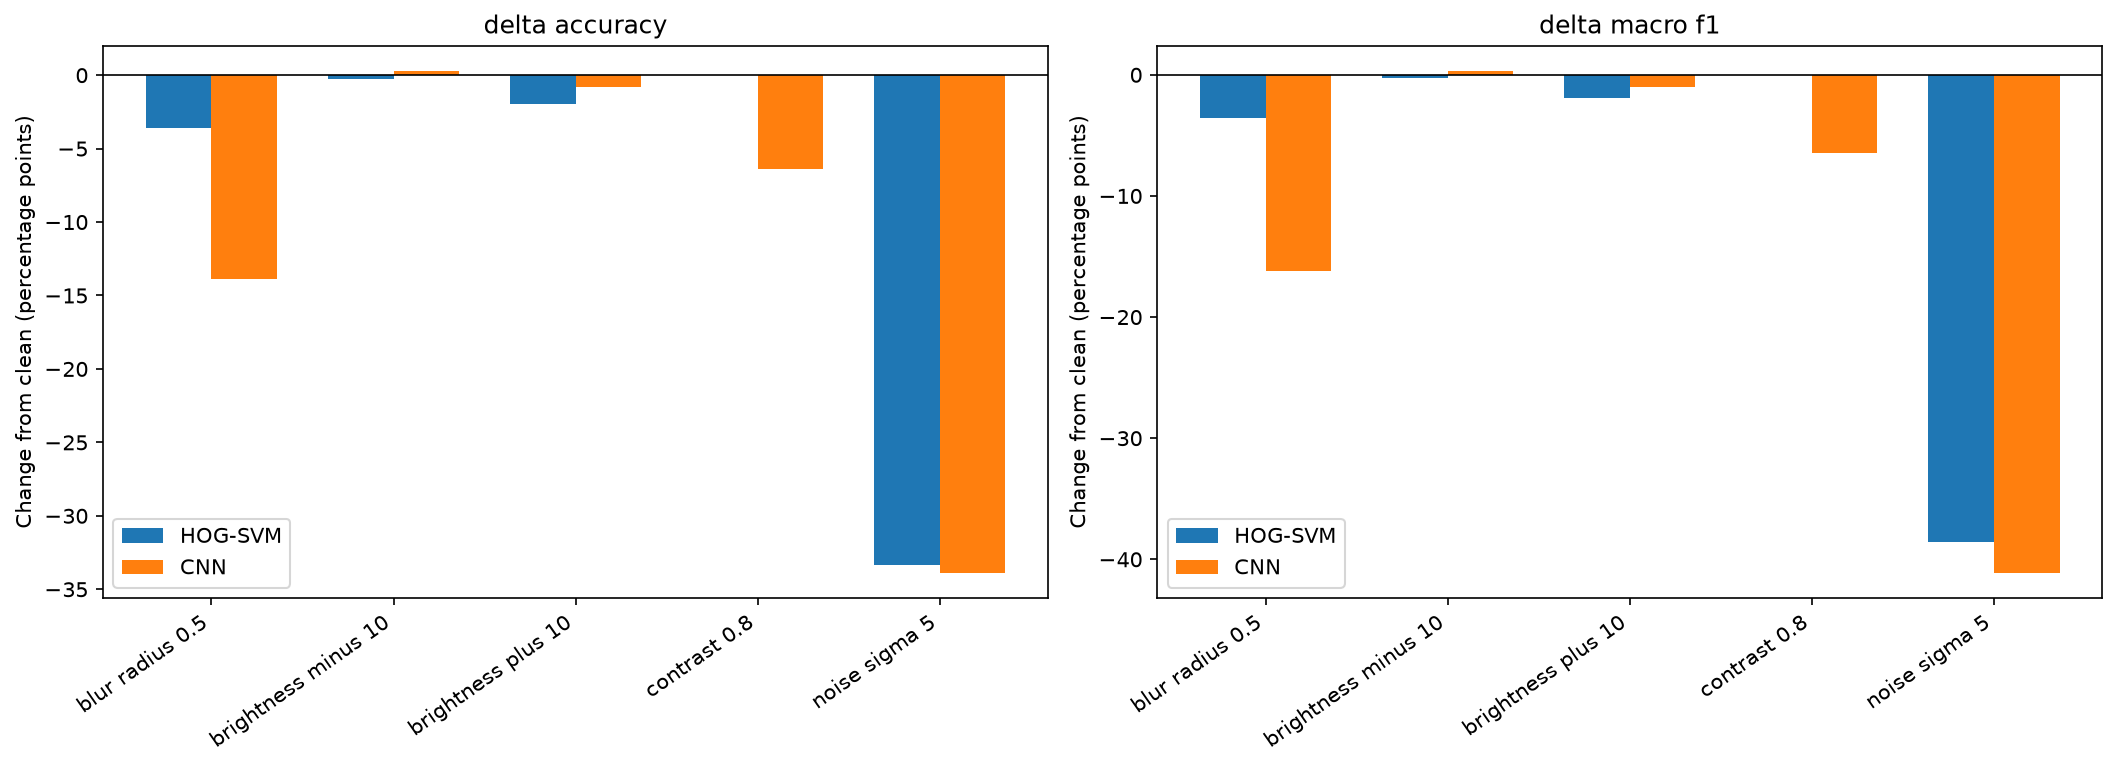

In [24]:
show_figure('outputs/experiments/05_comparison_xai_robustness/figures/robustness_deltas.png', 'Figure 6. Changes from clean performance under each declared stress.', width=1050)

### The clean ranking does not hold under every stress

Under radius-0.5 blur, HOG-SVM macro F1 is 0.8668, exceeding CNN's 0.7936. Under contrast factor 0.8, HOG-SVM remains at 0.9023, while CNN falls to 0.8911. Stability under uniform contrast reduction is consistent with the normalised HOG representation, but this observation does not isolate the responsible mechanism.

CNN retains higher absolute macro F1 under the two brightness shifts and Gaussian noise. However, under noise its drop from clean performance is larger: -0.4113, versus -0.3855 for HOG-SVM. Neither model is robust to that declared noise condition in the sense of maintaining its clean performance. A numerically small pixel perturbation is not necessarily mild for model performance. These findings make camera focus, noise and contrast relevant priorities for a future factory-specific evaluation; they do not warrant retrofitting preprocessing using this test set.

## 12. Computation, deployment and responsible use

Both methods are benchmarked on this same CPU with four numerical-library threads where supported. Timing uses the first 32 development images, avoiding additional main test evaluation. Batch sizes 1 and 32 use three warm-ups and ten timed repetitions. Stages distinguish warm file read/decode, preprocessing, model-only inference and file-to-prediction end-to-end latency. CNN preprocessing includes scaling and frozen normalisation; SVM preprocessing includes scaling and HOG, with its fitted StandardScaler inside model inference. Each stage is measured independently, so its median need not sum to the end-to-end median. Throughput is batch size divided by median time, not sustained production throughput. The raw samples, library thread settings and hardware description are retained.

Warm filesystem caching, operating-system scheduling and sequential benchmarking limit precision. Timings exclude camera acquisition, queueing, network transfer, process startup and service orchestration. File size is serialisation size, not working memory or installed runtime size. No edge device, cloud API, GPU, energy use or production service is benchmarked.

In [25]:
display(Markdown('**Table 18. Development computation for the exact frozen runs, in seconds. Scopes differ and are not a controlled speed comparison.**'))
display(pd.DataFrame([
    {'model':'HOG-SVM', 'stage':'HOG extraction, reads and hash checks', 'seconds':svm_result['feature_extraction_and_hash_seconds']},
    {'model':'HOG-SVM', 'stage':'Six-candidate five-fold search', 'seconds':svm_result['cv_search_wall_seconds']},
    {'model':'HOG-SVM', 'stage':'Final development pipeline fit', 'seconds':svm_result['final_development_fit_seconds']},
    {'model':'CNN', 'stage':'Five-fold training, diagnostics and checkpointing', 'seconds':cnn_result['total_cv_wall_seconds']},
    {'model':'CNN', 'stage':'Final 20-epoch development fit', 'seconds':cnn_result['final_refit_seconds']}
]))

**Table 18. Development computation for the exact frozen runs, in seconds. Scopes differ and are not a controlled speed comparison.**

,model,stage,seconds
0,HOG-SVM,"HOG extraction, reads and hash checks",18.693497
1,HOG-SVM,Six-candidate five-fold search,253.062504
2,HOG-SVM,Final development pipeline fit,9.018710
3,CNN,"Five-fold training, diagnostics and checkpointing",712.732040
4,CNN,Final 20-epoch development fit,104.714431


In [26]:
show_table('outputs/experiments/05_comparison_xai_robustness/tables/model_size_and_complexity.csv', 'Table 19. Serialised model size and representation complexity; blank entries are not applicable.', columns=None, index=False)

**Table 19. Serialised model size and representation complexity; blank entries are not applicable.**

model,file_bytes,cnn_parameter_count,hog_dimensions,support_vectors
HOG-SVM,24503366,,4356.000000,1246.000000
CNN,32865,6142.000000,,


In [27]:
timing = read_table(FINAL_RUN + '/tables/timing_summary.csv')
timing['p95_ms'] = timing.p95_seconds * 1000
display(Markdown('**Table 20. Same-CPU timing: independent stages, three warm-ups and ten repetitions. Time columns use milliseconds.**'))
display(timing[['model','batch_size','stage','median_ms','p95_ms','amortised_ms_per_image','images_per_second']].round(4))

**Table 20. Same-CPU timing: independent stages, three warm-ups and ten repetitions. Time columns use milliseconds.**

,model,batch_size,stage,median_ms,p95_ms,amortised_ms_per_image,images_per_second
0,CNN,1,end_to_end,7.0360,7.6036,7.0360,142.1262
1,CNN,1,file_read_decode,1.6627,2.7276,1.6627,601.4314
2,CNN,1,model_only,3.3480,4.2133,3.3480,298.6813
3,CNN,1,preprocessing,0.2049,0.3146,0.2049,4880.4297
4,CNN,32,end_to_end,91.2540,98.4128,2.8517,350.6696
5,CNN,32,file_read_decode,41.0682,46.4017,1.2834,779.1926
6,CNN,32,model_only,38.9507,40.6096,1.2172,821.5503
7,CNN,32,preprocessing,7.9872,8.7888,0.2496,4006.4353
8,HOG-SVM,1,end_to_end,29.3515,36.5423,29.3515,34.0698
9,HOG-SVM,1,file_read_decode,1.2796,1.7575,1.2796,781.5247


On the recorded CPU, warm single-image end-to-end medians are **7.0360 ms for CNN** and **29.3515 ms for HOG-SVM**. At batch 32, amortised end-to-end times are **2.8517** and **25.1746 ms per image**, respectively. The CNN checkpoint is **32,865 bytes**, compared with **24,503,366 bytes** for the SVM artefact. The frozen CNN is therefore the faster and smaller serialised implementation in this benchmark, but installed runtime, peak memory, cold start and production service behaviour are not measured. Development training times must not be substituted for this controlled inference comparison.

### Ethics, limitations and responsible-use conditions

**Scope and consequences.** Every image in this benchmark is already assigned to a defect category. Neither model can establish that steel is defect-free, and accuracy here cannot be converted into defect detection sensitivity, false reject rates or safety assurance. Misclassification could send material to an unsuitable review or treatment route, increase scrap and rework, or delay recognition of a costly defect. The study does not quantify these operational costs or connect labels to engineering acceptance limits. A production system would require normal material, unknown defects and ambiguous examples, with domain experts defining the relevant consequences and acceptance criteria.

**Representativeness.** A balanced six-class archive does not reproduce factory prevalence or demonstrate robustness across cameras, steel grades, production lines, lighting or factories. Prior full-collection EDA, unverified equivalence to the original university archive and unknown acquisition groups further constrain generalisation. The present subgroup results identify audit priorities; the synthetic stresses probe selected image transformations. Neither resolves external validity. A later prospective evaluation should be separated by time and acquisition group, include multiple sites and retain factory metadata where lawful and appropriate.

**Human oversight and automation bias.** Confident errors and shared model failures make an unreviewed automatic disposition rule unjustified. A pilot should assist trained inspectors, preserve the image and model version, allow correction and escalation, and make uncertainty and scope visible. A Grad-CAM overlay is not an assurance badge. This notebook does not derive a rejection threshold, select an ensemble or optimise a cost policy from the test set. Any such policy needs development or newly collected validation data and an independently assessed operating point.

**Privacy and commercial sensitivity.** Steel crops may contain little personal information, but factory captures and metadata can reveal process settings, product identifiers, timestamps, client specifications or proprietary defects. Incidental people or identifiers in a wider acquisition stream require minimisation. Control access, retention and export; preserve traceability without unnecessary identifying data. Local inference may reduce transfer requirements but does not eliminate security duties. Cloud or API inference needs agreed data handling, encryption, access controls, service continuity and an assessment of network latency and commercial confidentiality. No legal compliance or safety certification is claimed here.

**Monitoring and change control.** During a supervised pilot, monitor camera settings, image-property distributions, missing/corrupt inputs, class prediction frequencies, review disagreement and delayed expert-labelled per-class errors. Input drift alone does not prove performance decline, while stable input summaries do not guarantee correctness. Define escalation rules with domain stakeholders, retain an audit trail, and review performance across equipment, shifts and grades. Retraining requires versioned data, documented label review, development-only model selection and a fresh independent evaluation. Retire this test set as a model-selection resource now that results are visible.

### Evidence-based answer and recommendation

For these frozen implementations, end-to-end representation learning improves clean held-out accuracy and macro F1, with a positive paired image-level interval. That gain is qualified by lower pitted-surface recall, complementary and shared errors, and reversals under blur and reduced contrast. The CNN leads on absolute macro F1 in three of five declared stresses, but loses more relative to its clean baseline under Gaussian noise. An average clean advantage does not establish uniformly safer behaviour.

**Recommendation:** prioritise the compact CNN for a supervised, factory-specific feasibility study because of its clean performance and measured CPU efficiency, while retaining HOG-SVM as a comparison for image-condition resilience. Neither is ready for autonomous acceptance or rejection of steel. This is a proposed next step, not a deployment outcome measured here. Collect independent data separated by time, acquisition group and site, including normal material, unfamiliar defects and ambiguous cases. Domain experts should define operational harms, review routes and acceptance criteria before evaluating an operating policy.

Any future calibration, preprocessing change, ensemble, model revision or confidence threshold requires development or newly collected validation data and a fresh independent evaluation. Do not optimise it on these now-visible test results. The archive's balanced classes, unknown acquisition dependence, prior full-collection EDA, differing selection budgets and unvalidated explanations limit the inference to this study. No numerical claim of operational savings, safety certification or general industrial readiness is made.

## 13. Optional input restoration and final integrity check

The default analysis does not need to decode raw images. The following optional cell is **disabled** and is not a full-training reproduction. If deliberately enabled, it downloads the recorded Figshare ZIP, verifies its size, MD5 and locally recorded SHA-256, rejects unsafe member paths and links, extracts into a new isolated directory, then checks every image against the frozen manifest. It never replaces `data/NEU-CLS`, split locks, predictions or models. Internet access and continued source availability are required. This network download/extraction path has not been executed for this consolidation.

To reproduce the executed analysis on another machine, copy this notebook and its inventoried relative-path evidence files, retain the directory layout and install the readback dependencies. The saved figures and tables are embedded in the executed notebook for reading; source artefacts are required only to rerun. The hashes establish consistency with the consolidated evidence, not independent scientific validity.

In [28]:
RESTORE_DATASET = False
if RESTORE_DATASET:
    from pathlib import PurePosixPath
    from urllib.request import urlopen
    import shutil
    import stat
    import zipfile

    restore = ROOT / 'outputs' / 'submission_input_restoration'
    restore.mkdir(parents=True, exist_ok=False)
    archive = restore / 'NEU-CLS.zip'
    with urlopen('https://ndownloader.figshare.com/files/54094775', timeout=60) as response, archive.open('xb') as target:
        shutil.copyfileobj(response, target)
    assert archive.stat().st_size == 27316154
    assert sha(archive) == 'df3f85c2826ac2f3b9fa1a9bc750781a80775c9fba00f7b8bc86138bfb4b1e94'
    assert hashlib.md5(archive.read_bytes()).hexdigest() == '19af5a1250d8ab0cb0828d31ee2b349d'
    extracted = restore / 'extracted'
    extracted.mkdir()
    with zipfile.ZipFile(archive) as z:
        members = z.infolist()
        for member in members:
            part = PurePosixPath(member.filename)
            assert not part.is_absolute() and '..' not in part.parts
            assert ':' not in member.filename and '\\' not in member.filename
            assert not stat.S_ISLNK(member.external_attr >> 16)
            assert (extracted / member.filename).resolve().is_relative_to(extracted.resolve())
        assert len([m for m in members if not m.is_dir()]) == 3602
        z.extractall(extracted)
    for row in manifest.itertuples():
        suffix = PurePosixPath(row.path).relative_to('data/NEU-CLS')
        candidates = [extracted / suffix, extracted / 'NEU-CLS' / suffix]
        matching = [p for p in candidates if p.is_file() and sha(p) == row.sha256]
        assert len(matching) == 1, row.path
    print('Restored inputs match every frozen image hash; original project data remain unchanged.')

## 14. Optional full reproduction: development training

Default execution validates the frozen numerical evidence from saved artefacts. The following implementation is provided for transparency and deliberate future reproduction, and **has not been executed in this consolidated notebook**. Its new code cells therefore have no execution counts or saved outputs. To enable both training sections, deliberately change `RUN_FULL_TRAINING` to `True` and run in order from the project root with the modelling dependencies listed in Section 1 installed.

The code is extracted from notebooks `03_classical_hog_svm.ipynb` and `04_deep_learning_cnn.ipynb`; neither notebook is imported or executed. It reuses the existing, checksum-verified manifests and shared five-fold stratified assignments, and needs the original images under `data/NEU-CLS`. Section 13's isolated restoration folder is not automatically substituted for that location. Only development images can be decoded. Test metadata is used solely for exclusion safeguards.

Training logic and model settings are retained. Each section uses a local scope and creates a new timestamped folder under `outputs/reproductions/` with collision refusal. Historical publication to latest-run pointers, plotting and timing-only benchmark code is omitted. The CNN verifies the exact frozen HOG-SVM result instead of a mutable latest-run pointer. New metrics and checkpoints belong only to the new folders and do not replace reported evidence. Numerical equality across environments has not been established.


In [ ]:
RUN_FULL_TRAINING = False


### 14.1 Optional full reproduction: HOG-SVM

Native 200 x 200 images are converted to greyscale float32 intensities in [0, 1]. Fixed HOG uses 9 orientations, 16 x 16 cells, 2 x 2 blocks and L2-Hys normalisation, producing 4,356 features. Each shared fold fits its own StandardScaler and SVC pipeline. The six candidates are linear/RBF kernels with C in {0.1, 1, 10} and gamma='scale'. Mean validation macro F1 selects the configuration, with declared candidate order breaking exact ties. Accuracy and macro precision, recall and F1 are calculated, including sample fold SD. The selected pipeline is refitted on all 1,439 development images and serialised separately.


In [ ]:
if RUN_FULL_TRAINING:
    def reproduce_hog_svm():
        # Source: 03_classical_hog_svm.ipynb, code cells 1, 3, 4, 6 and 10.
        from pathlib import Path
        from datetime import datetime, timezone
        from time import perf_counter
        from importlib.metadata import version
        import hashlib
        import json
        import platform
        import sys
        import warnings

        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        from PIL import Image
        from IPython.display import display
        from skimage.feature import hog
        from skimage.exposure import rescale_intensity
        from sklearn.pipeline import Pipeline
        from sklearn.preprocessing import StandardScaler
        from sklearn.svm import SVC
        from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay
        from sklearn.exceptions import ConvergenceWarning
        import joblib

        ROOT = Path.cwd().resolve()
        METRICS = ROOT / 'outputs' / 'metrics'
        REPORTS = ROOT / 'outputs' / 'reports'
        CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']
        SEED = 42
        def require(condition, message):
            if not bool(condition): raise RuntimeError(message)
        def digest(path): return hashlib.sha256(path.read_bytes()).hexdigest()
        def read_json(path): return json.loads(path.read_text(encoding='utf-8'))

        paths = {'manifest': METRICS/'data_split_manifest.csv', 'split_lock': METRICS/'split_lock.json',
                 'folds': METRICS/'development_cv_folds.csv', 'fold_lock': METRICS/'development_cv_lock.json',
                 'split_status': REPORTS/'02_split_status.json', 'fold_status': REPORTS/'02a_validation_status.json'}
        require(all(p.is_file() for p in paths.values()), 'Run notebooks 02 and 02a first.')
        source_digests = {key: digest(path) for key, path in paths.items()}
        lock, fold_lock = read_json(paths['split_lock']), read_json(paths['fold_lock'])
        split_status, fold_status = read_json(paths['split_status']), read_json(paths['fold_status'])
        require(split_status['status'] == fold_status['status'] == 'PASS', 'Preparation checks have not passed.')
        require(source_digests['manifest'] == lock['manifest_sha256'] == fold_lock['split_manifest_sha256']
                == split_status['manifest_sha256'] == fold_status['split_manifest_sha256'], 'Split checksum mismatch.')
        require(source_digests['folds'] == fold_lock['folds_sha256'] == fold_status['folds_sha256'], 'Fold checksum mismatch.')
        require(lock['classes'] == CLASSES and lock['seed'] == fold_lock['seed'] == SEED
                and fold_lock['n_folds'] == 5, 'Unexpected split/fold policy.')
        manifest = pd.read_csv(paths['manifest'], keep_default_na=False)
        folds = pd.read_csv(paths['folds'], keep_default_na=False)
        require(manifest.path.is_unique and folds.path.is_unique, 'Repeated image path.')
        development = manifest.loc[manifest.split.eq('development')].sort_values('path').reset_index(drop=True)
        require(len(development) == 1439 and set(development.class_name) == set(CLASSES), 'Unexpected development data.')
        require(set(folds.path) == set(development.path), 'Fold table does not exactly cover development.')
        folds = folds.set_index('path').loc[development.path].reset_index()
        for key in ['path', 'class_name', 'sha256', 'pixel_sha256']:
            require(folds[key].equals(development[key]), f'Fold metadata mismatch: {key}')
        development['validation_fold'] = folds.validation_fold.to_numpy()
        require(set(development.validation_fold) == set(range(5)), 'Invalid validation folds.')
        test_metadata = manifest.loc[manifest.split.eq('test')]
        for key in ['path', 'sha256', 'pixel_sha256']:
            require(development[key].is_unique and not (set(development[key]) & set(test_metadata[key])), f'Duplicate/leakage: {key}')
        cv=[]
        for fold in range(5):
            train=np.flatnonzero(development.validation_fold.to_numpy() != fold)
            valid=np.flatnonzero(development.validation_fold.to_numpy() == fold)
            require(set(development.iloc[train].class_name) == set(development.iloc[valid].class_name) == set(CLASSES), 'Missing fold class.')
            require(not set(train) & set(valid), 'Overlapping fold indices.')
            cv.append((train, valid))
        require(np.array_equal(np.sort(np.concatenate([v for _,v in cv])), np.arange(len(development))), 'OOF coverage is not exact.')
        print('PASS: verified split and five development folds; test image files have not been opened.')

        # Fixed HOG and bounded six-candidate search declaration.
        HOG_CONFIG = dict(orientations=9, pixels_per_cell=(16,16), cells_per_block=(2,2),
                          block_norm='L2-Hys', transform_sqrt=False, feature_vector=True, channel_axis=None)
        CANDIDATES = [{'kernel': kernel, 'C': c, 'gamma': 'scale'}
                      for kernel in ['linear','rbf'] for c in [0.1,1.0,10.0]]
        run_id = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
        RUN = ROOT/'outputs'/'reproductions'/('03_hog_svm_'+run_id)
        RUN.mkdir(parents=True, exist_ok=False)
        environment = {'python': platform.python_version(), 'executable': sys.executable,
                       'platform': platform.platform(), 'processor': platform.processor(),
                       'packages': {p: version(p) for p in ['numpy','pandas','matplotlib','pillow','scikit-image','scikit-learn','joblib']}}
        protocol = {'run_id':run_id, 'seed':SEED, 'source_digests':source_digests,
                    'input_size':[200,200], 'grayscale':'Pillow L / 255, float32', 'hog':HOG_CONFIG,
                    'candidates':CANDIDATES, 'selection_metric':'mean five-fold macro F1',
                    'tie_break':'declared candidate order', 'environment':environment,
                    'scope':'development only; test evaluation deferred'}
        (RUN/'protocol.json').write_text(json.dumps(protocol,indent=2),encoding='utf-8')
        (RUN/'status.json').write_text(json.dumps({'status':'IN_PROGRESS'}),encoding='utf-8')
        print('Run folder:', RUN)
        display(pd.DataFrame(CANDIDATES))

        # Development-only greyscale loading and HOG extraction.
        opened_paths=set()
        allowed_paths=set(development.path)
        def load_development_image(relative_path):
            require(relative_path in allowed_paths, 'Attempt to load a non-development image.')
            path=(ROOT/relative_path).resolve()
            require(path.is_relative_to((ROOT/'data'/'NEU-CLS').resolve()), 'Image path outside dataset.')
            with Image.open(path) as image:
                require(image.size == (200,200), 'Unexpected image dimensions.')
                array=np.asarray(image.convert('L'),dtype=np.float32)/255.0
            opened_paths.add(relative_path)
            return array

        start=perf_counter()
        features=[]
        for row in development.itertuples():
            require(digest(ROOT/row.path) == row.sha256, f'Changed development image: {row.path}')
            features.append(hog(load_development_image(row.path), **HOG_CONFIG))
        X=np.asarray(features,dtype=np.float32)
        y=development.class_name.to_numpy()
        feature_seconds=perf_counter()-start
        require(X.shape == (1439,4356) and np.isfinite(X).all(), f'Invalid HOG matrix: {X.shape}')
        print(f'HOG shape: {X.shape}; matrix: {X.nbytes/1024**2:.1f} MiB; extraction + integrity checks: {feature_seconds:.2f}s')



        # Shared validation folds, fold-local scaling, selection and metrics.
        def make_model(params):
            return Pipeline([('scale',StandardScaler()),
                             ('svm',SVC(**params,cache_size=256,random_state=SEED))])
        def metrics(truth,prediction):
            precision,recall,f1,_=precision_recall_fscore_support(truth,prediction,labels=CLASSES,average='macro',zero_division=0)
            return {'accuracy':accuracy_score(truth,prediction),'precision_macro':precision,
                    'recall_macro':recall,'f1_macro':f1}

        rows=[]
        candidate_predictions={}
        search_start=perf_counter()
        for candidate_id,params in enumerate(CANDIDATES):
            oof=np.full(len(y),'',dtype=object)
            for fold,(train,valid) in enumerate(cv):
                model=make_model(params)
                start=perf_counter()
                with warnings.catch_warnings():
                    warnings.simplefilter('error',ConvergenceWarning)
                    model.fit(X[train],y[train])
                fit_seconds=perf_counter()-start
                require(int(model.named_steps['scale'].n_samples_seen_) == len(train), 'Scaler trained on wrong sample count.')
                require(np.allclose(model.named_steps['scale'].mean_, X[train].mean(axis=0,dtype=np.float64)), 'Scaler statistics mismatch.')
                start=perf_counter()
                prediction=model.predict(X[valid])
                predict_seconds=perf_counter()-start
                oof[valid]=prediction
                rows.append({'candidate_id':candidate_id,**params,'fold':fold,'train_images':len(train),
                             'validation_images':len(valid),**metrics(y[valid],prediction),
                             'fit_seconds':fit_seconds,'predict_seconds':predict_seconds})
                pd.DataFrame(rows).to_csv(RUN/'cv_fold_metrics.csv',index=False)
                print(f'Candidate {candidate_id+1}/6, fold {fold+1}/5: macro F1={rows[-1]["f1_macro"]:.4f}; fit={fit_seconds:.1f}s',flush=True)
            require(np.isin(oof,CLASSES).all(), 'Missing OOF predictions.')
            candidate_predictions[candidate_id]=oof
        search_seconds=perf_counter()-search_start
        fold_metrics=pd.DataFrame(rows)
        summary=[]
        for candidate_id,params in enumerate(CANDIDATES):
            group=fold_metrics.loc[fold_metrics.candidate_id.eq(candidate_id)]
            result={'candidate_id':candidate_id,**params}
            for metric in ['accuracy','precision_macro','recall_macro','f1_macro']:
                result[metric+'_mean']=group[metric].mean()
                result[metric+'_std']=group[metric].std(ddof=1)
            result['fit_seconds_total']=group.fit_seconds.sum()
            summary.append(result)
        summary=pd.DataFrame(summary).sort_values(['f1_macro_mean','candidate_id'],ascending=[False,True])
        summary.to_csv(RUN/'cv_candidate_summary.csv',index=False)
        best_id=int(summary.iloc[0].candidate_id)
        best_params=CANDIDATES[best_id]
        selected_folds=fold_metrics.loc[fold_metrics.candidate_id.eq(best_id)].copy()
        selected_folds.to_csv(RUN/'selected_fold_metrics.csv',index=False)
        display(summary)
        print('Selected configuration:',best_params)

        # Selected out-of-fold metrics and final development refit.
        oof = candidate_predictions[best_id]
        print('Selected pooled development OOF metrics:', metrics(y, oof))
        final_model=make_model(best_params)
        start=perf_counter()
        with warnings.catch_warnings():
            warnings.simplefilter('error',ConvergenceWarning)
            final_model.fit(X,y)
        final_fit_seconds=perf_counter()-start
        require(int(final_model.named_steps['scale'].n_samples_seen_) == 1439, 'Final fit size mismatch.')
        model_path=RUN/'hog_svm_development.joblib'
        joblib.dump({'pipeline':final_model,'hog_config':HOG_CONFIG,'classes':CLASSES,
                     'input_size':(200,200),'grayscale':'Pillow L / 255, float32',
                     'split_manifest_sha256':source_digests['manifest'],
                     'folds_sha256':source_digests['folds'],'selected_params':best_params},model_path,compress=3)
        # Small serialisation check; this is not a training-set performance report.
        loaded=joblib.load(model_path)
        require(np.array_equal(final_model.predict(X[:6]),loaded['pipeline'].predict(X[:6])), 'Saved model prediction mismatch.')
        require(opened_paths == allowed_paths, 'Unexpected image access coverage.')
        require(not opened_paths & set(test_metadata.path), 'Test image opened.')
        require(all(digest(path) == source_digests[key] for key,path in paths.items()), 'Preparation artefacts changed during run.')
        require(all(digest(ROOT/r.path) == r.sha256 for r in development.itertuples()), 'Development files changed during run.')


        print('Optional HOG-SVM reproduction saved separately:', RUN)

    reproduce_hog_svm()


### 14.2 Optional full reproduction: compact CNN

The Dataset and DataLoader retain native one-channel 200 x 200 handling, batch size 32 and no augmentation. Each fold estimates its mean and population SD from its training pixels only. The exact three Conv2d/BatchNorm/non-inplace ReLU/MaxPool blocks use 8, 16 and 32 channels, followed by adaptive average pooling, dropout 0.25 and six output logits. The named `conv3` layer and checkpoint layout remain compatible with the later Captum LayerGradCam analysis.

CPU deterministic algorithms and seeds 42 to 46 are retained. AdamW uses learning rate 0.001 and weight decay 0.0001 with cross-entropy loss. Training and evaluation modes are separate, and validation must not update BatchNorm buffers. Strictly higher validation macro F1 saves a checkpoint, preserving the earliest tie; five non-improving epochs stop training, within a 25-epoch cap.

The original final-refit rule is the ceiling of the median selected fold epoch. The frozen selected epochs [20, 15, 8, 23, 23] give **20 development-refit epochs**, with seed 142 and normalisation fitted on all development images. A deliberate future run applies that same rule to its own fold results; it does not tune against the test set or silently replace the frozen 20-epoch model. The original class definition and training logic below are retained, without running synthetic optimisation or attribution during notebook preparation.


In [ ]:
if RUN_FULL_TRAINING:
    def reproduce_cnn():
        # Source: 04_deep_learning_cnn.ipynb, code cells 2, 4, 6, 8, 10, 12-16 and 20.
        from pathlib import Path
        from datetime import datetime, timezone
        from time import perf_counter
        from importlib.metadata import version
        import hashlib
        import json
        import math
        import os
        import platform
        import random
        import sys

        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        from PIL import Image
        from IPython.display import display
        import torch
        from torch import nn
        from torch.utils.data import Dataset, DataLoader
        from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

        ROOT = Path.cwd().resolve()
        METRICS = ROOT / 'outputs' / 'metrics'
        REPORTS = ROOT / 'outputs' / 'reports'
        CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']
        CLASS_TO_INDEX = {name: i for i, name in enumerate(CLASSES)}
        CHECKS = []
        def require(name, passed, detail=''):
            CHECKS.append({'check': name, 'status': 'PASS' if bool(passed) else 'FAIL', 'detail': str(detail)})
            if not bool(passed):
                raise RuntimeError(f'{name}: {detail}')
        def file_sha(path):
            h=hashlib.sha256()
            with path.open('rb') as handle:
                for block in iter(lambda: handle.read(1024*1024), b''): h.update(block)
            return h.hexdigest()
        def read_json(path): return json.loads(path.read_text(encoding='utf-8'))
        def write_json(path, value):
            temporary=path.with_suffix(path.suffix+'.tmp')
            temporary.write_text(json.dumps(value,indent=2,allow_nan=False), encoding='utf-8')
            temporary.replace(path)

        ARTIFACTS = {
            'manifest': METRICS/'data_split_manifest.csv', 'split_lock': METRICS/'split_lock.json',
            'folds': METRICS/'development_cv_folds.csv', 'fold_lock': METRICS/'development_cv_lock.json',
            'split_status': REPORTS/'02_split_status.json', 'fold_status': REPORTS/'02a_validation_status.json',
            'classical_result': ROOT/'outputs/experiments/03_hog_svm_20260923T232217_532748Z/result.json'}
        require('Required preparation artefacts exist', all(p.is_file() for p in ARTIFACTS.values()))
        source_hashes={name:file_sha(path) for name,path in ARTIFACTS.items()}
        split_lock=read_json(ARTIFACTS['split_lock'])
        fold_lock=read_json(ARTIFACTS['fold_lock'])
        split_status=read_json(ARTIFACTS['split_status'])
        fold_status=read_json(ARTIFACTS['fold_status'])
        require('Preparation passed', split_status['status']==fold_status['status']=='PASS')
        require('Split hashes agree', source_hashes['manifest']==split_lock['manifest_sha256']==fold_lock['split_manifest_sha256']
                ==split_status['manifest_sha256']==fold_status['split_manifest_sha256'])
        require('Fold hashes agree', source_hashes['folds']==fold_lock['folds_sha256']==fold_status['folds_sha256'])
        require('Fixed protocol recognised', split_lock['classes']==CLASSES and split_lock['seed']==fold_lock['seed']==42
                and fold_lock['n_folds']==5 and split_lock['test_size']==0.2)
        classical_result_path=ARTIFACTS['classical_result']
        require('Frozen classical result verified', file_sha(classical_result_path)==EVIDENCE_SHA256[classical_result_path.relative_to(ROOT).as_posix()])
        classical_result=read_json(classical_result_path)
        require('Same folds as classical model', classical_result['status']=='PASS' and
                classical_result['source_digests']['manifest']==source_hashes['manifest'] and
                classical_result['source_digests']['folds']==source_hashes['folds'] and
                classical_result['test_evaluation_performed'] is False)
        ARTIFACTS['classical_result']=classical_result_path
        source_hashes['classical_result']=file_sha(classical_result_path)

        manifest=pd.read_csv(ARTIFACTS['manifest'],keep_default_na=False)
        folds=pd.read_csv(ARTIFACTS['folds'],keep_default_na=False)
        require('Manifest path uniqueness', manifest.path.is_unique and folds.path.is_unique)
        development=manifest.loc[manifest.split.eq('development')].sort_values('path').reset_index(drop=True)
        require('Development count and classes', len(development)==1439 and set(development.class_name)==set(CLASSES))
        require('Folds exactly cover development', set(folds.path)==set(development.path))
        folds=folds.set_index('path').loc[development.path].reset_index()
        for column in ['path','class_name','sha256','pixel_sha256']:
            require(f'Fold metadata agrees: {column}', folds[column].equals(development[column]))
        development['validation_fold']=folds.validation_fold.to_numpy()
        require('Exactly five predefined folds', set(development.validation_fold)==set(range(5)))
        for column in ['sha256','pixel_sha256']:
            require(f'Unique development content: {column}', development[column].is_unique)
        ALLOWED_PATHS=frozenset(development.path)
        NON_DEVELOPMENT_PATHS=frozenset(manifest.loc[~manifest.split.eq('development'),'path'])
        require('Development permission boundary disjoint', not ALLOWED_PATHS & NON_DEVELOPMENT_PATHS)
        FOLD_INDICES=[]
        for fold in range(5):
            train=np.flatnonzero(development.validation_fold.to_numpy()!=fold)
            valid=np.flatnonzero(development.validation_fold.to_numpy()==fold)
            require(f'Fold {fold}: disjoint and complete', not set(train)&set(valid) and len(train)+len(valid)==1439)
            require(f'Fold {fold}: all six classes', set(development.iloc[train].class_name)==set(development.iloc[valid].class_name)==set(CLASSES))
            FOLD_INDICES.append((train,valid))
        require('Validation coverage exactly once', np.array_equal(np.sort(np.concatenate([v for _,v in FOLD_INDICES])),np.arange(1439)))
        # Remove the full manifest so modelling functions cannot accidentally select its test rows.
        del manifest, folds
        print('PASS: same locked split and five folds as HOG-SVM; no image files opened yet.')

        # Original CPU settings, deterministic algorithms and seeds.
        DEVICE=torch.device('cpu')
        CONFIG={'seed':42,'channels':[8,16,32],'input_shape':[1,200,200],
                'first_conv_stride':2,'dropout':0.25,'learning_rate':0.001,'weight_decay':0.0001,
                'batch_size':32,'max_epochs':25,'patience':5,'threads':min(4,os.cpu_count() or 1),
                'num_workers':0,'augmentation':'none','selection':'strictly highest validation macro F1; earliest tie',
                'refit_epoch_rule':'ceiling of median best fold epoch'}
        torch.set_num_threads(CONFIG['threads'])
        torch.use_deterministic_algorithms(True)
        def seed_everything(seed):
            random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        seed_everything(CONFIG['seed'])
        environment={'python':platform.python_version(),'executable':sys.executable,'platform':platform.platform(),
            'processor':platform.processor(),'logical_cpus':os.cpu_count(),'torch_threads':torch.get_num_threads(),
            'device':str(DEVICE),'cuda_available':torch.cuda.is_available(),
            'deterministic_algorithms':torch.are_deterministic_algorithms_enabled(),
            'packages':{p:version(p) for p in ['torch','torchvision','numpy','pandas','matplotlib','pillow','scikit-learn']}}
        try: environment['packages']['captum']=version('captum')
        except Exception: environment['packages']['captum']='not installed; optional for later explanations'
        run_id=datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ')
        RUN=ROOT/'outputs'/'reproductions'/('04_cnn_'+run_id)
        RUN.mkdir(parents=True,exist_ok=False)
        (RUN/'checkpoints').mkdir()
        write_json(RUN/'status.json',{'status':'IN_PROGRESS','stage':'safeguards'})
        write_json(RUN/'protocol.json',{'run_id':run_id,'config':CONFIG,'classes':CLASSES,
            'class_to_index':CLASS_TO_INDEX,'source_hashes':source_hashes,'environment':environment,
            'interpretation':'development checkpoint selection, not final test or nested validation'})
        print('Run:',RUN)
        print(json.dumps(environment,indent=2))

        # Development-only Dataset, DataLoader and training-fold normalisation.
        image_access=[]
        def load_allowed_image(relative_path):
            if relative_path not in ALLOWED_PATHS:
                raise PermissionError('Only the development allow-list may be opened in notebook 04.')
            path=(ROOT/relative_path).resolve()
            if not path.is_relative_to((ROOT/'data'/'NEU-CLS').resolve()):
                raise PermissionError('Image path escaped the dataset directory.')
            with Image.open(path) as image:
                if image.size!=(200,200): raise ValueError(f'Unexpected size: {relative_path}')
                array=np.array(image.convert('L'),dtype=np.uint8)
            image_access.append(relative_path)
            return array

        before_access=len(image_access)
        try:
            load_allowed_image(sorted(NON_DEVELOPMENT_PATHS)[0])
        except PermissionError:
            denied_correctly=True
        else:
            denied_correctly=False
        require('Non-development loader request blocked before access', denied_correctly and len(image_access)==before_access)
        start=perf_counter()
        images=np.empty((len(development),200,200),dtype=np.uint8)
        for index,row in enumerate(development.itertuples()):
            require(f'Image hash {index}',file_sha(ROOT/row.path)==row.sha256,row.path)
            images[index]=load_allowed_image(row.path)
        load_seconds=perf_counter()-start
        labels=np.array([CLASS_TO_INDEX[x] for x in development.class_name],dtype=np.int64)
        require('All and only development images loaded', set(image_access)==set(ALLOWED_PATHS) and len(image_access)==1439)

        def training_normalisation(indices):
            # Computed over training pixels only, in float64 to avoid integer overflow.
            pixels=images[indices]
            mean=float(pixels.mean(dtype=np.float64)/255.0)
            std=float(pixels.std(dtype=np.float64)/255.0)
            if not math.isfinite(mean) or not math.isfinite(std) or std<=1e-8:
                raise ValueError('Invalid training normalisation.')
            return mean,std

        class DevelopmentDataset(Dataset):
            def __init__(self,indices,mean,std):
                self.indices=np.array(indices,dtype=np.int64)
                if not len(self.indices) or len(set(self.indices))!=len(self.indices) or self.indices.min()<0 or self.indices.max()>=len(development):
                    raise ValueError('Dataset indices must be unique development rows.')
                self.mean,self.std=float(mean),float(std)
            def __len__(self): return len(self.indices)
            def __getitem__(self,index):
                position=int(self.indices[index])
                x=torch.from_numpy(images[position]).unsqueeze(0).float().div(255.0)
                x=(x-self.mean)/self.std
                return x,int(labels[position]),position

        def make_loader(indices,mean,std,shuffle=False,seed=42):
            generator=torch.Generator().manual_seed(seed)
            return DataLoader(DevelopmentDataset(indices,mean,std),batch_size=CONFIG['batch_size'],
                shuffle=shuffle,drop_last=False,num_workers=0,generator=generator)

        normalisation=[]
        for fold,(train,valid) in enumerate(FOLD_INDICES):
            mean,std=training_normalisation(train)
            normalisation.append({'fold':fold,'mean':mean,'std':std,'training_images':len(train),
                'validation_images':len(valid),'fitted_on':'training subset only'})
        pd.DataFrame(normalisation).to_csv(RUN/'fold_normalisation.csv',index=False)
        display(pd.DataFrame(normalisation))
        print(f'Cached {len(images)} development images: {images.nbytes/1024**2:.1f} MiB, {load_seconds:.1f}s including integrity checks.')

        # Exact CompactCNN and state_dict names; conv3 remains the Captum target.
        class CompactCNN(nn.Module):
            def __init__(self,dropout=0.25):
                super().__init__()
                self.conv1=nn.Conv2d(1,8,3,stride=2,padding=1,bias=False)
                self.bn1=nn.BatchNorm2d(8)
                self.conv2=nn.Conv2d(8,16,3,padding=1,bias=False)
                self.bn2=nn.BatchNorm2d(16)
                self.conv3=nn.Conv2d(16,32,3,padding=1,bias=False)
                self.bn3=nn.BatchNorm2d(32)
                self.relu=nn.ReLU(inplace=False)
                self.pool=nn.MaxPool2d(2)
                self.average=nn.AdaptiveAvgPool2d((1,1))
                self.dropout=nn.Dropout(dropout)
                self.classifier=nn.Linear(32,len(CLASSES))
            def forward(self,x):
                x=self.pool(self.relu(self.bn1(self.conv1(x))))
                x=self.pool(self.relu(self.bn2(self.conv2(x))))
                x=self.pool(self.relu(self.bn3(self.conv3(x))))
                x=self.average(x).flatten(1)
                return self.classifier(self.dropout(x))

        def new_model(seed):
            seed_everything(seed)
            return CompactCNN(CONFIG['dropout']).to(DEVICE)



        # Loss, AdamW, evaluation, strict macro-F1 selection and patience stopping.
        LOSS=nn.CrossEntropyLoss()
        def classification_metrics(truth,pred):
            precision,recall,f1,_=precision_recall_fscore_support(truth,pred,labels=np.arange(6),average='macro',zero_division=0)
            return {'accuracy':float(accuracy_score(truth,pred)),'precision_macro':float(precision),
                    'recall_macro':float(recall),'f1_macro':float(f1)}

        def train_epoch(model,loader,optimizer):
            model.train()
            total_loss,total=0.0,0
            for x,y,_ in loader:
                x,y=x.to(DEVICE),y.to(DEVICE)
                optimizer.zero_grad(set_to_none=True)
                logits=model(x)
                loss=LOSS(logits,y)
                if not torch.isfinite(loss): raise RuntimeError('Non-finite training loss.')
                loss.backward()
                optimizer.step()
                total_loss+=float(loss.detach())*len(y)
                total+=len(y)
            if total!=len(loader.dataset): raise RuntimeError('Training coverage mismatch.')
            return total_loss/total

        @torch.inference_mode()
        def evaluate(model,loader):
            model.eval()
            before={name:buffer.clone() for name,buffer in model.named_buffers()}
            truth,pred,positions=[],[],[]
            total_loss,total=0.0,0
            for x,y,index in loader:
                logits=model(x.to(DEVICE))
                loss=LOSS(logits,y.to(DEVICE))
                if not torch.isfinite(logits).all() or not torch.isfinite(loss):
                    raise RuntimeError('Non-finite evaluation output.')
                total_loss+=float(loss)*len(y); total+=len(y)
                truth.extend(y.numpy().tolist()); pred.extend(logits.argmax(1).cpu().numpy().tolist())
                positions.extend(index.numpy().tolist())
            if total!=len(loader.dataset) or sorted(positions)!=sorted(loader.dataset.indices.tolist()):
                raise RuntimeError('Evaluation coverage mismatch.')
            if not all(torch.equal(before[name],buffer) for name,buffer in model.named_buffers()):
                raise RuntimeError('BatchNorm buffers changed during evaluation.')
            return {'loss':total_loss/total,**classification_metrics(truth,pred)},np.array(positions),np.array(pred)

        def checkpoint_payload(model,fold,epoch,score,mean,std,seed):
            return {'state_dict':{k:v.detach().cpu().clone() for k,v in model.state_dict().items()},
                'fold':fold,'epoch':epoch,'validation_macro_f1':score,'mean':float(mean),'std':float(std),
                'classes':CLASSES,'class_to_index':CLASS_TO_INDEX,'config':CONFIG,'seed':seed,
                'manifest_sha256':source_hashes['manifest'],'folds_sha256':source_hashes['folds']}

        def save_checkpoint(path,payload):
            temporary=path.with_suffix('.pt.tmp')
            torch.save(payload,temporary)
            temporary.replace(path)

        fold_results=[]
        all_histories=[]
        oof_predictions=np.full(len(development),-1,dtype=np.int64)
        oof_coverage=np.zeros(len(development),dtype=np.int64)
        evaluation_registry=[]

        def run_fold(fold):
            train,valid=FOLD_INDICES[fold]
            seed=CONFIG['seed']+fold
            mean,std=normalisation[fold]['mean'],normalisation[fold]['std']
            model=new_model(seed)
            optimizer=torch.optim.AdamW(model.parameters(),lr=CONFIG['learning_rate'],weight_decay=CONFIG['weight_decay'])
            train_loader=make_loader(train,mean,std,shuffle=True,seed=seed)
            train_diagnostic_loader=make_loader(train,mean,std)
            valid_loader=make_loader(valid,mean,std)
            best_score,best_epoch,stale=-math.inf,0,0
            history=[]
            checkpoint=RUN/'checkpoints'/f'fold_{fold}_best.pt'
            fold_start=perf_counter()
            for epoch in range(1,CONFIG['max_epochs']+1):
                start=perf_counter()
                online_loss=train_epoch(model,train_loader,optimizer)
                fit_seconds=perf_counter()-start
                start=perf_counter()
                train_metrics,_,_=evaluate(model,train_diagnostic_loader)
                train_diagnostic_seconds=perf_counter()-start
                start=perf_counter()
                valid_metrics,_,_=evaluate(model,valid_loader)
                validation_seconds=perf_counter()-start
                improved=valid_metrics['f1_macro']>best_score
                if improved:
                    best_score,best_epoch,stale=valid_metrics['f1_macro'],epoch,0
                    save_checkpoint(checkpoint,checkpoint_payload(model,fold,epoch,best_score,mean,std,seed))
                else:
                    stale+=1
                history.append({'fold':fold,'epoch':epoch,'online_train_loss':online_loss,
                    'train_loss':train_metrics['loss'],'train_macro_f1':train_metrics['f1_macro'],
                    'validation_loss':valid_metrics['loss'],'validation_macro_f1':valid_metrics['f1_macro'],
                    'fit_seconds':fit_seconds,'train_diagnostic_seconds':train_diagnostic_seconds,
                    'validation_seconds':validation_seconds,'selected_checkpoint':improved,'patience_used':stale})
                pd.DataFrame(history).to_csv(RUN/f'fold_{fold}_history.csv',index=False)
                write_json(RUN/'progress.json',{'stage':'cross_validation','fold':fold,'epoch':epoch,
                    'best_epoch':best_epoch,'best_validation_macro_f1':best_score,'patience_used':stale})
                print(f'Fold {fold+1}/5 | epoch {epoch:02d}/{CONFIG["max_epochs"]} | train F1 {train_metrics["f1_macro"]:.4f} | validation F1 {valid_metrics["f1_macro"]:.4f} | best {best_epoch} | patience {stale}/{CONFIG["patience"]}',flush=True)
                if stale>=CONFIG['patience']: break
            fold_wall_seconds=perf_counter()-fold_start
            payload=torch.load(checkpoint,map_location='cpu',weights_only=True)
            model.load_state_dict(payload['state_dict'])
            start=perf_counter()
            selected_metrics,positions,predictions=evaluate(model,valid_loader)
            selected_prediction_seconds=perf_counter()-start
            require(f'Fold {fold}: best checkpoint reproduced',abs(selected_metrics['f1_macro']-best_score)<1e-12)
            require(f'Fold {fold}: no repeated OOF predictions',np.all(oof_coverage[positions]==0))
            require(f'Fold {fold}: checkpoint epoch selection',best_epoch==int(pd.DataFrame(history).loc[lambda t:t.validation_macro_f1.eq(t.validation_macro_f1.max()),'epoch'].iloc[0]))
            oof_predictions[positions]=predictions
            oof_coverage[positions]+=1
            evaluation_registry.extend({'fold':fold,'path':str(development.iloc[i].path),'role':'selected_checkpoint_validation'} for i in positions)
            row={'fold':fold,'seed':seed,'train_images':len(train),'validation_images':len(valid),
                'best_epoch':best_epoch,'epochs_run':len(history),'stop_reason':'patience' if stale>=CONFIG['patience'] else 'epoch_limit',
                **selected_metrics,'fold_wall_seconds':fold_wall_seconds,
                'optimisation_seconds':sum(r['fit_seconds'] for r in history),
                'selected_validation_seconds':selected_prediction_seconds,
                'checkpoint_bytes':checkpoint.stat().st_size,'checkpoint_sha256':file_sha(checkpoint)}
            fold_results.append(row)
            all_histories.extend(history)
            pd.DataFrame(fold_results).to_csv(RUN/'fold_metrics.csv',index=False)
            pd.DataFrame(all_histories).to_csv(RUN/'all_fold_histories.csv',index=False)
            print(f'Fold {fold+1} complete: selected epoch {best_epoch}, macro F1 {best_score:.4f}',flush=True)

        # Five shared folds, with a 25-epoch maximum per fold.
        for fold in range(5):
            run_fold(fold)
        require('All five folds completed', len(fold_results)==5 and {r['fold'] for r in fold_results}==set(range(5)))
        require('Exactly one OOF prediction per development image', np.all(oof_coverage==1))
        fold_metrics=pd.DataFrame(fold_results).sort_values('fold').reset_index(drop=True)
        metric_names=['accuracy','precision_macro','recall_macro','f1_macro']
        display(fold_metrics[metric_names].agg(['mean','std']))
        print('Pooled development OOF metrics:', classification_metrics(labels,oof_predictions))


        # Ceiling-of-median selected epoch rule: 20 epochs in the frozen experiment.
        refit_epochs=int(math.ceil(float(np.median(fold_metrics.best_epoch))))
        refit_seed=CONFIG['seed']+100
        all_indices=np.arange(len(development))
        final_mean,final_std=training_normalisation(all_indices)
        final_model=new_model(refit_seed)
        final_optimizer=torch.optim.AdamW(final_model.parameters(),lr=CONFIG['learning_rate'],weight_decay=CONFIG['weight_decay'])
        final_loader=make_loader(all_indices,final_mean,final_std,shuffle=True,seed=refit_seed)
        refit_history=[]
        start_refit=perf_counter()
        for epoch in range(1,refit_epochs+1):
            start=perf_counter()
            loss=train_epoch(final_model,final_loader,final_optimizer)
            refit_history.append({'epoch':epoch,'online_training_loss':loss,'fit_seconds':perf_counter()-start})
            pd.DataFrame(refit_history).to_csv(RUN/'final_development_refit_history.csv',index=False)
            write_json(RUN/'progress.json',{'stage':'final_development_refit','epoch':epoch,'epoch_limit':refit_epochs})
            print(f'Development refit epoch {epoch}/{refit_epochs}: online loss {loss:.4f}',flush=True)
        refit_seconds=perf_counter()-start_refit
        final_model.eval()
        final_path=RUN/'checkpoints'/'cnn_final_development.pt'
        save_checkpoint(final_path,checkpoint_payload(final_model,'all_development',refit_epochs,None,final_mean,final_std,refit_seed))
        restored=CompactCNN(CONFIG['dropout']).to(DEVICE)
        restored.load_state_dict(torch.load(final_path,map_location='cpu',weights_only=True)['state_dict'])
        restored.eval()
        sample_x,_,_=next(iter(make_loader(all_indices[:32],final_mean,final_std)))
        with torch.inference_mode():
            expected=final_model(sample_x)
            actual=restored(sample_x)
        require('Final checkpoint round-trip logits identical',torch.equal(expected,actual))



        require('Development-only access preserved', set(image_access)==set(ALLOWED_PATHS) and not set(image_access)&set(NON_DEVELOPMENT_PATHS))
        require('Preparation artefacts unchanged', all(file_sha(path)==source_hashes[name] for name,path in ARTIFACTS.items()))
        require('Development files unchanged', all(file_sha(ROOT/r.path)==r.sha256 for r in development.itertuples()))
        pd.DataFrame(CHECKS).to_csv(RUN/'acceptance_checks.csv',index=False)
        write_json(RUN/'status.json',{'status':'PASS','test_evaluation_performed':False,'refit_epochs':refit_epochs})
        print('Optional CNN reproduction saved separately:', RUN)

    reproduce_cnn()


In [29]:
# Read-only recheck after all displays and metric verification.
changed = [relative for relative, digest in EVIDENCE_SHA256.items() if sha(ROOT / relative) != digest]
assert not changed, f'Evidence changed during readback: {changed}'
print(f'PASS: {len(EVIDENCE_SHA256)} evidence files verified; clean, per-class, confusion, subgroup and stress metrics agree with frozen predictions.')
print('No training, model inference, split regeneration or experimental evidence writes were performed by the default analysis.')

PASS: 60 evidence files verified; clean, per-class, confusion, subgroup and stress metrics agree with frozen predictions.
No training, model inference, split regeneration or experimental evidence writes were performed by the default analysis.


## References

References support methods and interpretation, not claims that this configuration is optimal. Web references were consulted on 27 September 2026; Figshare metadata and checksums are supported by the corrected local provenance record of that date. That record remains the source for the documented local verification chain.

1. Song, K. and Yan, Y. (n.d.). *NEU surface defect database*. Northeastern University. [Original dataset description and attribution](https://faculty.neu.edu.cn/songkc/en/zdylm/263265/list/).
2. Song, K. and Yan, Y. (2013). A noise robust method based on completed local binary patterns for hot-rolled steel strip surface defects. *Applied Surface Science*, 285, pp. 858–864. Original dataset reference listed by [the university source](https://faculty.neu.edu.cn/songkc/en/zdylm/263265/list/). This study does not reproduce its method or compare its reported scores.
3. Cao, W. (2025). *NEU-CLS*, version 1. Figshare. [doi:10.6084/m9.figshare.28903550.v1](https://doi.org/10.6084/m9.figshare.28903550.v1). [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). [Recorded archive download](https://ndownloader.figshare.com/files/54094775).
4. Dalal, N. and Triggs, B. (2005). Histograms of oriented gradients for human detection. *IEEE Conference on Computer Vision and Pattern Recognition*, 1, pp. 886–893. [doi:10.1109/CVPR.2005.177](https://doi.org/10.1109/CVPR.2005.177). [Paper](https://www.cs.princeton.edu/courses/archive/fall13/cos429/papers/Dalal05.pdf).
5. Cortes, C. and Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20, pp. 273–297. [doi:10.1007/BF00994018](https://doi.org/10.1007/BF00994018).
6. LeCun, Y., Bengio, Y. and Hinton, G. (2015). Deep learning. *Nature*, 521, pp. 436–444. [doi:10.1038/nature14539](https://doi.org/10.1038/nature14539).
7. Selvaraju, R. R., Cogswell, M., Das, A., Vedantam, R., Parikh, D. and Batra, D. (2017). Grad-CAM: Visual explanations from deep networks via gradient-based localization. *IEEE International Conference on Computer Vision*. [Author manuscript and publication history](https://arxiv.org/abs/1610.02391).
8. Adebayo, J., Gilmer, J., Muelly, M., Goodfellow, I., Hardt, M. and Kim, B. (2018). Sanity checks for saliency maps. *Advances in Neural Information Processing Systems*. [Author manuscript](https://arxiv.org/abs/1810.03292).
9. Hendrycks, D. and Dietterich, T. (2019). Benchmarking neural network robustness to common corruptions and perturbations. *International Conference on Learning Representations*. [Author manuscript](https://arxiv.org/abs/1903.12261).
10. Captum contributors (n.d.). *LayerGradCam API documentation*. [Layer attribution](https://captum.ai/api/layer.html#layer-gradcam). Software used: Captum 0.9.0.
11. Koh, P. W. et al. (2021). WILDS: A benchmark of in-the-wild distribution shifts. *Proceedings of Machine Learning Research*, 139, pp. 5637–5664. [Primary publication](https://proceedings.mlr.press/v139/koh21a.html).

**Project evidence:** current notebooks 01, 02, 02a, 03, 04, 04a and 05; `METHODOLOGY.md`; `data/NEU-CLS/Dataset-Information.txt`; the frozen source inventory and relative-path artefacts identified above. Historical prose is not substituted for the corrected provenance or the numerical results of the final model runs.